# Full-Spectrum Inverse Design using Conditional Invertible Neural Networks (cINN)
### This notebook implements a cINN (Normalizing Flow) to solve the one-to-many acoustic inverse design problem.

In [15]:
# # %%
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from multiprocessing import Pool, cpu_count
# import warnings
# import math
# import matplotlib.pyplot as plt

# # # --- Google Drive Mounting ---
# # from google.colab import drive
# # drive.mount('/content/drive')

# warnings.filterwarnings("ignore")

# # Device setup
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# n_cores = cpu_count()
# print(f"Device: {device} | CPU Cores for Physics: {n_cores}")


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from multiprocessing import Pool, cpu_count
import warnings
import math
import matplotlib.pyplot as plt
import os

warnings.filterwarnings("ignore")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_cores = cpu_count()
print(f"Device: {device} | CPU Cores for Physics: {n_cores}")

# ADDED: Check GPU capability for physics engine
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    USE_GPU_PHYSICS = True
else:
    USE_GPU_PHYSICS = False
    print("GPU not available - using CPU for physics engine")

# Get current working directory
CURRENT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
print(f"Working Directory: {CURRENT_DIR}")

Device: cuda | CPU Cores for Physics: 4
GPU: Tesla T4
GPU Memory: 15.64 GB
Working Directory: /kaggle/working


# 1. Physics engine (TMM) 
### Evaluates 20 parameters to calculate the 1000-point absorption spectrum (1-1000 Hz).

In [18]:
# # %%
# PARAM_RANGES = {
#     'd1': (1.0, 20.0), 'd2': (1.0, 20.0), 'd3': (1.0, 20.0), 'd4': (1.0, 20.0), 'd5': (1.0, 20.0),
#     'd6': (1.0, 20.0), 'd7': (1.0, 20.0), 'd8': (1.0, 20.0), 'd9': (1.0, 20.0), 'd10': (1.0, 20.0),
#     'm2': (20.0, 1980.0), 'm3': (20.0, 1980.0), 'm5': (20.0, 1980.0),
#     'm6': (20.0, 1980.0), 'm8': (20.0, 1980.0), 'm9': (20.0, 1980.0),
#     'rho': (1000.0, 1500.0), 'eta': (0.1, 0.8), 'E': (1e7, 1e8), 'nu': (0.4, 0.49)
# }
# PARAM_NAMES = list(PARAM_RANGES.keys())

# def validate_and_clip_parameters(params):
#     lower = np.array([PARAM_RANGES[n][0] for n in PARAM_NAMES])
#     upper = np.array([PARAM_RANGES[n][1] for n in PARAM_NAMES])
#     clipped = np.clip(params, lower, upper)

#     # Dynamic constraint for Young's Modulus based on loss factor
#     eta_vals = clipped[:, 17]
#     E_vals = clipped[:, 18]
#     E_min = 1e7 * (1 + eta_vals)
#     E_max = 1e8 * (1 + eta_vals)
#     clipped[:, 18] = np.clip(E_vals, E_min, E_max)
#     return clipped

# def calculate_absorption_full_curve(params_row):
#     param_tensor = torch.from_numpy(params_row.reshape(1, -1)).float()
#     W, rho_w, c_w = 2.0, 1000.0, 1500.0
#     Z_w = rho_w * c_w
#     frequencies = torch.arange(1, 1001, 1, dtype=torch.float32)
#     omega = 2 * np.pi * frequencies
#     num_freq = len(frequencies)
#     hollow_layer_indices = [1, 2, 4, 5, 7, 8]

#     d_vals = param_tensor[:, 0:10] / 1000.0
#     m_vals = param_tensor[:, 10:16] / 1000.0
#     rho_r, eta, E_r, nu = param_tensor[:, 16:17], param_tensor[:, 17:18], param_tensor[:, 18:19], param_tensor[:, 19:20]
#     E_c = E_r * (1 + 1j * eta)
#     lam = (E_c * nu) / ((1 + nu) * (1 - 2 * nu))
#     mu = E_c / (2 * (1 + nu))

#     eye_matrix = torch.eye(2, dtype=torch.complex64)
#     T_total = eye_matrix.unsqueeze(0).unsqueeze(0).repeat(1, num_freq, 1, 1)

#     for lay_idx in range(10):
#         d = d_vals[:, lay_idx:lay_idx+1]
#         eps = torch.zeros((1, 1), dtype=torch.float32)
#         if lay_idx in hollow_layer_indices:
#             m_ptr = hollow_layer_indices.index(lay_idx)
#             eps = m_vals[:, m_ptr:m_ptr+1] / W
#         rho_eff = rho_r * (1 - eps**2)
#         numerator = (mu * (lam + 2*mu) * (eps**2 + 1)) + (2 * (eps**2) * lam)
#         denominator = ((lam + mu) * eps**2) + mu
#         mask = torch.abs(denominator) < 1e-15
#         S_eff = torch.where(mask, numerator * 1e15, numerator / denominator)
#         c_eff = torch.sqrt(S_eff / rho_eff)
#         k_eff = omega.unsqueeze(0) / c_eff
#         Z_eff = rho_eff * c_eff
#         cos_kd, sin_kd = torch.cos(k_eff * d), torch.sin(k_eff * d)
#         Z_eff_mask = torch.abs(Z_eff) < 1e-15
#         t21 = torch.where(Z_eff_mask, torch.full_like(cos_kd, 1e15), 1j * sin_kd / Z_eff)
#         T_i = torch.zeros((1, num_freq, 2, 2), dtype=torch.complex64)
#         T_i[:, :, 0, 0], T_i[:, :, 0, 1] = cos_kd, 1j * Z_eff * sin_kd
#         T_i[:, :, 1, 0], T_i[:, :, 1, 1] = t21, cos_kd
#         T_total = torch.matmul(T_total, T_i)

#     T11, T21 = T_total[:, :, 0, 0], T_total[:, :, 1, 0]
#     mask = torch.abs(T21) < 1e-15
#     Z_in = torch.where(mask, torch.full_like(T21, 1e15), T11 / T21)
#     R = torch.where(mask, torch.ones_like(T21, dtype=torch.complex64), (Z_in - Z_w) / (Z_in + Z_w))
#     alpha = torch.clamp((1 - torch.abs(R)**2).real, 0.0, 1.0)
#     return alpha[0].cpu().numpy()

# def batch_physics_evaluation(param_matrix):
#     with Pool(processes=n_cores) as pool:
#         results = pool.map(calculate_absorption_full_curve, param_matrix)
#     return np.array(results)



In [34]:
# %%
PARAM_RANGES = {
    'd1': (1.0, 20.0), 'd2': (1.0, 20.0), 'd3': (1.0, 20.0), 'd4': (1.0, 20.0), 'd5': (1.0, 20.0),
    'd6': (1.0, 20.0), 'd7': (1.0, 20.0), 'd8': (1.0, 20.0), 'd9': (1.0, 20.0), 'd10': (1.0, 20.0),
    'm2': (20.0, 1980.0), 'm3': (20.0, 1980.0), 'm5': (20.0, 1980.0),
    'm6': (20.0, 1980.0), 'm8': (20.0, 1980.0), 'm9': (20.0, 1980.0),
    'rho': (1000.0, 1500.0), 'eta': (0.1, 0.8), 'E': (1e7, 1e8), 'nu': (0.4, 0.49)
}
PARAM_NAMES = list(PARAM_RANGES.keys())

def validate_and_clip_parameters(params):
    lower = np.array([PARAM_RANGES[n][0] for n in PARAM_NAMES])
    upper = np.array([PARAM_RANGES[n][1] for n in PARAM_NAMES])
    clipped = np.clip(params, lower, upper)

    # Dynamic constraint for Young's Modulus based on loss factor
    eta_vals = clipped[:, 17]
    E_vals = clipped[:, 18]
    E_min = 1e7 * (1 + eta_vals)
    E_max = 1e8 * (1 + eta_vals)
    clipped[:, 18] = np.clip(E_vals, E_min, E_max)
    return clipped


# MODIFIED: GPU-accelerated version
def calculate_absorption_full_curve_gpu(params_tensor, device=device):
    """
    GPU-accelerated TMM calculation.
    
    Parameters
    ----------
    params_tensor : torch.Tensor, shape (batch_size, 20)
        Batch of parameter sets
    device : torch.device
        Device to run calculations on
    
    Returns
    -------
    torch.Tensor, shape (batch_size, 1000)
        Absorption coefficients
    """
    params_tensor = params_tensor.to(device)
    batch_size = params_tensor.shape[0]
    
    W, rho_w, c_w = 2.0, 1000.0, 1500.0
    Z_w = rho_w * c_w
    frequencies = torch.arange(1, 1001, 1, dtype=torch.float32, device=device)
    omega = 2 * np.pi * frequencies
    num_freq = len(frequencies)
    hollow_layer_indices = [1, 2, 4, 5, 7, 8]

    # Extract parameters (all operations on GPU)
    d_vals = params_tensor[:, 0:10] / 1000.0  # (batch, 10)
    m_vals = params_tensor[:, 10:16] / 1000.0  # (batch, 6)
    rho_r = params_tensor[:, 16:17]  # (batch, 1)
    eta = params_tensor[:, 17:18]
    E_r = params_tensor[:, 18:19]
    nu = params_tensor[:, 19:20]
    
    E_c = E_r * (1 + 1j * eta)
    lam = (E_c * nu) / ((1 + nu) * (1 - 2 * nu))
    mu = E_c / (2 * (1 + nu))

    # Initialize transfer matrix for all batches
    eye_matrix = torch.eye(2, dtype=torch.complex64, device=device)
    T_total = eye_matrix.unsqueeze(0).unsqueeze(0).repeat(batch_size, num_freq, 1, 1)

    # Process each layer
    for lay_idx in range(10):
        d = d_vals[:, lay_idx:lay_idx+1]  # (batch, 1)
        eps = torch.zeros((batch_size, 1), dtype=torch.float32, device=device)
        
        if lay_idx in hollow_layer_indices:
            m_ptr = hollow_layer_indices.index(lay_idx)
            eps = m_vals[:, m_ptr:m_ptr+1] / W
        
        rho_eff = rho_r * (1 - eps**2)
        numerator = (mu * (lam + 2*mu) * (eps**2 + 1)) + (2 * (eps**2) * lam)
        denominator = ((lam + mu) * eps**2) + mu
        
        mask = torch.abs(denominator) < 1e-15
        S_eff = torch.where(mask, numerator * 1e15, numerator / denominator)
        c_eff = torch.sqrt(S_eff / rho_eff)
        
        # Broadcast to all frequencies: (batch, freq)
        k_eff = omega.unsqueeze(0) / c_eff  # (batch, freq)
        Z_eff = rho_eff * c_eff  # (batch, 1)
        
        cos_kd = torch.cos(k_eff * d)  # (batch, freq)
        sin_kd = torch.sin(k_eff * d)
        
        Z_eff_mask = torch.abs(Z_eff) < 1e-15
        t21 = torch.where(Z_eff_mask, torch.full_like(cos_kd, 1e15), 1j * sin_kd / Z_eff)
        
        # Build transfer matrix (batch, freq, 2, 2)
        T_i = torch.zeros((batch_size, num_freq, 2, 2), dtype=torch.complex64, device=device)
        T_i[:, :, 0, 0] = cos_kd
        T_i[:, :, 0, 1] = 1j * Z_eff * sin_kd
        T_i[:, :, 1, 0] = t21
        T_i[:, :, 1, 1] = cos_kd
        
        T_total = torch.matmul(T_total, T_i)

    # Calculate absorption
    T11 = T_total[:, :, 0, 0]  # (batch, freq)
    T21 = T_total[:, :, 1, 0]
    
    mask = torch.abs(T21) < 1e-15
    Z_in = torch.where(mask, torch.full_like(T21, 1e15), T11 / T21)
    R = torch.where(mask, torch.ones_like(T21, dtype=torch.complex64), (Z_in - Z_w) / (Z_in + Z_w))
    alpha = torch.clamp((1 - torch.abs(R)**2).real, 0.0, 1.0)
    
    return alpha  # (batch, 1000)


# CPU version (fallback)
def calculate_absorption_full_curve(params_row):
    """CPU version - single sample at a time"""
    param_tensor = torch.from_numpy(params_row.reshape(1, -1)).float()
    W, rho_w, c_w = 2.0, 1000.0, 1500.0
    Z_w = rho_w * c_w
    frequencies = torch.arange(1, 1001, 1, dtype=torch.float32)
    omega = 2 * np.pi * frequencies
    num_freq = len(frequencies)
    hollow_layer_indices = [1, 2, 4, 5, 7, 8]

    d_vals = param_tensor[:, 0:10] / 1000.0
    m_vals = param_tensor[:, 10:16] / 1000.0
    rho_r, eta, E_r, nu = param_tensor[:, 16:17], param_tensor[:, 17:18], param_tensor[:, 18:19], param_tensor[:, 19:20]
    E_c = E_r * (1 + 1j * eta)
    lam = (E_c * nu) / ((1 + nu) * (1 - 2 * nu))
    mu = E_c / (2 * (1 + nu))

    eye_matrix = torch.eye(2, dtype=torch.complex64)
    T_total = eye_matrix.unsqueeze(0).unsqueeze(0).repeat(1, num_freq, 1, 1)

    for lay_idx in range(10):
        d = d_vals[:, lay_idx:lay_idx+1]
        eps = torch.zeros((1, 1), dtype=torch.float32)
        if lay_idx in hollow_layer_indices:
            m_ptr = hollow_layer_indices.index(lay_idx)
            eps = m_vals[:, m_ptr:m_ptr+1] / W
        rho_eff = rho_r * (1 - eps**2)
        numerator = (mu * (lam + 2*mu) * (eps**2 + 1)) + (2 * (eps**2) * lam)
        denominator = ((lam + mu) * eps**2) + mu
        mask = torch.abs(denominator) < 1e-15
        S_eff = torch.where(mask, numerator * 1e15, numerator / denominator)
        c_eff = torch.sqrt(S_eff / rho_eff)
        k_eff = omega.unsqueeze(0) / c_eff
        Z_eff = rho_eff * c_eff
        cos_kd, sin_kd = torch.cos(k_eff * d), torch.sin(k_eff * d)
        Z_eff_mask = torch.abs(Z_eff) < 1e-15
        t21 = torch.where(Z_eff_mask, torch.full_like(cos_kd, 1e15), 1j * sin_kd / Z_eff)
        T_i = torch.zeros((1, num_freq, 2, 2), dtype=torch.complex64)
        T_i[:, :, 0, 0], T_i[:, :, 0, 1] = cos_kd, 1j * Z_eff * sin_kd
        T_i[:, :, 1, 0], T_i[:, :, 1, 1] = t21, cos_kd
        T_total = torch.matmul(T_total, T_i)

    T11, T21 = T_total[:, :, 0, 0], T_total[:, :, 1, 0]
    mask = torch.abs(T21) < 1e-15
    Z_in = torch.where(mask, torch.full_like(T21, 1e15), T11 / T21)
    R = torch.where(mask, torch.ones_like(T21, dtype=torch.complex64), (Z_in - Z_w) / (Z_in + Z_w))
    alpha = torch.clamp((1 - torch.abs(R)**2).real, 0.0, 1.0)
    return alpha[0].cpu().numpy()


def batch_physics_evaluation(param_matrix, batch_size=256):
    """
    Batch evaluation with automatic GPU/CPU selection.
    
    Parameters
    ----------
    param_matrix : np.ndarray, shape (N, 20)
        Parameter sets to evaluate
    batch_size : int
        Batch size for GPU processing
    
    Returns
    -------
    np.ndarray, shape (N, 1000)
        Absorption spectra
    """
    if USE_GPU_PHYSICS and torch.cuda.is_available():
        # GPU batch processing
        # print(f"   Using GPU acceleration (batch size: {batch_size})")
        num_samples = param_matrix.shape[0]
        all_results = []
        
        for i in range(0, num_samples, batch_size):
            batch = param_matrix[i:i+batch_size]
            batch_tensor = torch.from_numpy(batch).float()
            
            with torch.no_grad():
                batch_results = calculate_absorption_full_curve_gpu(batch_tensor, device)
            
            all_results.append(batch_results.cpu().numpy())
        
        return np.vstack(all_results)
    
    else:
        # CPU multiprocessing fallback
        print(f"   Using CPU multiprocessing ({n_cores} cores)")
        with Pool(processes=n_cores) as pool:
            results = pool.map(calculate_absorption_full_curve, param_matrix)
        return np.array(results)


print(f"✅ Physics Engine configured:")
print(f"   Mode: {'GPU-accelerated' if USE_GPU_PHYSICS else 'CPU multiprocessing'}")
print(f"   Device: {device}")

✅ Physics Engine configured:
   Mode: GPU-accelerated
   Device: cuda


# 2. Data loading and preprocessing

In [21]:
# %%
# UPDATE THIS PATH to exactly where your .npz file is located in your Google Drive
npz_file_path = '/kaggle/input/datasets/vimipatel/fsd-npz/full_spectrum_data.npz'

print(f"Loading dataset from {npz_file_path}...")
data = np.load(npz_file_path)

# Print keys to help you identify how the arrays are named inside the .npz file
keys = data.files
print(f"Found arrays in .npz file: {keys}")

# NOTE: Adjust the keys below if your arrays are named differently
# (e.g., if you used np.savez(..., params=X, spectra=Y), use data['params'])
# If you used np.savez without naming them, they default to 'arr_0', 'arr_1'.
X_params = data[keys[0]]  # Expecting shape (N, 20)
Y_spectra = data[keys[1]] # Expecting shape (N, 1000)

print(f"Parameters shape: {X_params.shape} | Spectra shape: {Y_spectra.shape}")

X_params = validate_and_clip_parameters(X_params)

# Standardize parameters (Zero mean, Unit variance)
scaler_params = StandardScaler()
X_norm = scaler_params.fit_transform(X_params)

X_train, X_test, Y_train, Y_test = train_test_split(X_norm, Y_spectra, test_size=0.1, random_state=42)
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(Y_train)), batch_size=256, shuffle=True)
print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")



Loading dataset from /kaggle/input/datasets/vimipatel/fsd-npz/full_spectrum_data.npz...
Found arrays in .npz file: ['parameters', 'spectra', 'param_names', 'spectrum_names', 'average_absorption', 'description', 'num_samples', 'num_params', 'num_freqs', 'generation_method', 'parameter_bounds']
Parameters shape: (100000, 20) | Spectra shape: (100000, 1000)
Training samples: 90000 | Testing samples: 10000


In [33]:
# ============================================================================
# DATA INTEGRITY VALIDATION
# ============================================================================
print("\n" + "="*80)
print("🔍 DATA INTEGRITY VALIDATION")
print("="*80)

# 1. Check for NaN/Inf values
print("\n1️⃣  Checking for invalid values...")
params_has_nan = np.isnan(X_params).any()
params_has_inf = np.isinf(X_params).any()
spectra_has_nan = np.isnan(Y_spectra).any()
spectra_has_inf = np.isinf(Y_spectra).any()

print(f"   Parameters - NaN: {params_has_nan} | Inf: {params_has_inf}")
print(f"   Spectra    - NaN: {spectra_has_nan} | Inf: {spectra_has_inf}")

if params_has_nan or params_has_inf or spectra_has_nan or spectra_has_inf:
    print("   ❌ WARNING: Invalid values detected!")
else:
    print("   ✅ No invalid values found")

# 2. Check parameter ranges
print("\n2️⃣  Validating parameter ranges...")
all_in_range = True
for idx, param_name in enumerate(PARAM_NAMES):
    min_val, max_val = PARAM_RANGES[param_name]
    actual_min = X_params[:, idx].min()
    actual_max = X_params[:, idx].max()
    in_range = (actual_min >= min_val) and (actual_max <= max_val)
    
    if not in_range:
        print(f"   ❌ {param_name}: [{actual_min:.2f}, {actual_max:.2f}] (expected [{min_val}, {max_val}])")
        all_in_range = False

if all_in_range:
    print("   ✅ All parameters within expected ranges")

# 3. Check absorption spectrum validity (should be [0, 1])
print("\n3️⃣  Validating absorption spectra...")
spectra_min = Y_spectra.min()
spectra_max = Y_spectra.max()
spectra_valid = (spectra_min >= 0.0) and (spectra_max <= 1.0)

print(f"   Range: [{spectra_min:.6f}, {spectra_max:.6f}]")
if spectra_valid:
    print("   ✅ All absorption values in valid range [0, 1]")
else:
    print(f"   ❌ WARNING: Out-of-range absorption values detected!")

# 4. Check data distribution
print("\n4️⃣  Data distribution analysis...")
print(f"   Training set: {len(X_train):,} samples ({100*len(X_train)/(len(X_train)+len(X_test)):.1f}%)")
print(f"   Test set:     {len(X_test):,} samples ({100*len(X_test)/(len(X_train)+len(X_test)):.1f}%)")

# 5. Check for duplicates
print("\n5️⃣  Checking for duplicate samples...")
unique_params = np.unique(X_params, axis=0)
num_duplicates = len(X_params) - len(unique_params)
print(f"   Duplicate parameter sets: {num_duplicates}")
if num_duplicates == 0:
    print("   ✅ No duplicates found")
else:
    print(f"   ⚠️  Found {num_duplicates} duplicate parameter sets")

print("\n" + "="*80)


🔍 DATA INTEGRITY VALIDATION

1️⃣  Checking for invalid values...
   Parameters - NaN: False | Inf: False
   Spectra    - NaN: False | Inf: False
   ✅ No invalid values found

2️⃣  Validating parameter ranges...
   ✅ All parameters within expected ranges

3️⃣  Validating absorption spectra...
   Range: [0.000702, 0.999997]
   ✅ All absorption values in valid range [0, 1]

4️⃣  Data distribution analysis...
   Training set: 90,000 samples (90.0%)
   Test set:     10,000 samples (10.0%)

5️⃣  Checking for duplicate samples...
   Duplicate parameter sets: 0
   ✅ No duplicates found



# 3. Invertible architecture definition
### Implements the Spectrum Encoder and the Conditional Affine Coupling blocks.

In [23]:
# %%
class SpectrumEncoder(nn.Module):
    def __init__(self, input_dim=1000, hidden_dim=256, embed_dim=128):
        super().__init__()
        # Compresses the 1000-point curve into a dense 128-d feature vector
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, embed_dim)
        )
    def forward(self, c):
        return self.net(c)

class CondAffineCoupling(nn.Module):
    def __init__(self, dim=20, cond_dim=128, hidden_dim=256):
        super().__init__()
        self.dim = dim
        self.half_dim = dim // 2

        # Sub-network to predict scale (s) and translation (t) factors
        self.net = nn.Sequential(
            nn.Linear(self.half_dim + cond_dim, hidden_dim), nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, dim) # Outputs concatenated [s, t]
        )

    def forward(self, x, cond, rev=False):
        x1, x2 = x[:, :self.half_dim], x[:, self.half_dim:]

        st = self.net(torch.cat([x1, cond], dim=1))
        s, t = st[:, :self.half_dim], st[:, self.half_dim:]
        s = torch.clamp(s, -3.0, 3.0)

        if not rev:
            y1 = x1
            y2 = x2 * torch.exp(s) + t
            log_det_J = torch.sum(s, dim=1)
            return torch.cat([y1, y2], dim=1), log_det_J
        else:
            y1 = x1
            y2 = (x2 - t) * torch.exp(-s)
            return torch.cat([y1, y2], dim=1)

class FullSpectrum_cINN(nn.Module):
    def __init__(self, num_blocks=8, param_dim=20, spectrum_dim=1000, cond_dim=128):
        super().__init__()
        self.encoder = SpectrumEncoder(spectrum_dim, 256, cond_dim)
        self.blocks = nn.ModuleList([CondAffineCoupling(param_dim, cond_dim, 256) for _ in range(num_blocks)])

    def forward(self, x, c, rev=False):
        cond_emb = self.encoder(c)
        log_det_J_total = 0

        if not rev:
            for block in self.blocks:
                x, log_det_J = block(x, cond_emb, rev=False)
                log_det_J_total += log_det_J
                x = torch.flip(x, dims=[1]) # Swap halves
            return x, log_det_J_total
        else:
            for block in reversed(self.blocks):
                x = torch.flip(x, dims=[1]) # Un-swap halves
                x = block(x, cond_emb, rev=True)
            return x



# 4. Training the network (Maximum Likelihood)

In [25]:
# # ### 4. Training the Network (Maximum Likelihood) with Validation Tracking

# # Create the Validation Loader (You already defined X_test and Y_test in Phase 2!)
# val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(Y_test)), batch_size=256, shuffle=False)

# model = FullSpectrum_cINN(num_blocks=8).to(device)
# optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# def nll_loss(z, log_det_J):
#     return torch.mean(0.5 * torch.sum(z**2, dim=1) - log_det_J)

# # Lists to store the loss values for plotting
# train_losses = []
# val_losses = []

# print("Training cINN and tracking Validation Loss...")
# for epoch in range(50):
#     # --- TRAINING PHASE ---
#     model.train()
#     train_loss = 0
#     for batch_x, batch_cond in train_loader:
#         batch_x, batch_cond = batch_x.to(device), batch_cond.to(device)

#         optimizer.zero_grad()
#         z, log_det_J = model(batch_x, batch_cond, rev=False)
#         loss = nll_loss(z, log_det_J)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         optimizer.step()
#         train_loss += loss.item()
    
#     avg_train_loss = train_loss / len(train_loader)
#     train_losses.append(avg_train_loss)

#     # --- VALIDATION PHASE ---
#     model.eval()
#     val_loss = 0
#     with torch.no_grad(): # No gradients needed for validation!
#         for val_x, val_cond in val_loader:
#             val_x, val_cond = val_x.to(device), val_cond.to(device)
#             z_val, log_det_J_val = model(val_x, val_cond, rev=False)
#             v_loss = nll_loss(z_val, log_det_J_val)
#             val_loss += v_loss.item()
            
#     avg_val_loss = val_loss / len(val_loader)
#     val_losses.append(avg_val_loss)

#     scheduler.step()
    
#     # Print progress every 5 epochs
#     if (epoch + 1) % 5 == 0:
#         print(f"Epoch {epoch+1:2d}/50 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
# # --- PLOTTING THE LEARNING CURVES ---
# plt.figure(figsize=(8, 5))
# plt.plot(range(1, 51), train_losses, label='Training Loss', color='blue', linewidth=2)
# plt.plot(range(1, 51), val_losses, label='Validation Loss', color='red', linestyle='--', linewidth=2)
# plt.title('cINN Learning Curves: NLL Loss over 50 Epochs')
# plt.xlabel('Epochs')
# plt.ylabel('Negative Log-Likelihood (NLL)')
# plt.legend()
# plt.grid(True)
# plt.show()

In [26]:
# # ### 4. Training the Network (Maximum Likelihood) with Validation Tracking (100 epochs)

# # Create the Validation Loader (You already defined X_test and Y_test in Phase 2!)
# val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(Y_test)), batch_size=256, shuffle=False)

# model = FullSpectrum_cINN(num_blocks=8).to(device)
# optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# def nll_loss(z, log_det_J):
#     return torch.mean(0.5 * torch.sum(z**2, dim=1) - log_det_J)

# # Lists to store the loss values for plotting
# train_losses = []
# val_losses = []

# print("Training cINN and tracking Validation Loss...")
# for epoch in range(100):
#     # --- TRAINING PHASE ---
#     model.train()
#     train_loss = 0
#     for batch_x, batch_cond in train_loader:
#         batch_x, batch_cond = batch_x.to(device), batch_cond.to(device)

#         optimizer.zero_grad()
#         z, log_det_J = model(batch_x, batch_cond, rev=False)
#         loss = nll_loss(z, log_det_J)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         optimizer.step()
#         train_loss += loss.item()
    
#     avg_train_loss = train_loss / len(train_loader)
#     train_losses.append(avg_train_loss)

#     # --- VALIDATION PHASE ---
#     model.eval()
#     val_loss = 0
#     with torch.no_grad(): # No gradients needed for validation!
#         for val_x, val_cond in val_loader:
#             val_x, val_cond = val_x.to(device), val_cond.to(device)
#             z_val, log_det_J_val = model(val_x, val_cond, rev=False)
#             v_loss = nll_loss(z_val, log_det_J_val)
#             val_loss += v_loss.item()
            
#     avg_val_loss = val_loss / len(val_loader)
#     val_losses.append(avg_val_loss)

#     scheduler.step()
    
#     # Print progress every 5 epochs
#     if (epoch + 1) % 5 == 0:
#         print(f"Epoch {epoch+1:2d}/100 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
# # --- PLOTTING THE LEARNING CURVES ---
# plt.figure(figsize=(8, 5))
# plt.plot(range(1, 101), train_losses, label='Training Loss', color='blue', linewidth=2)
# plt.plot(range(1, 101), val_losses, label='Validation Loss', color='red', linestyle='--', linewidth=2)
# plt.title('cINN Learning Curves: NLL Loss over 100 Epochs')
# plt.xlabel('Epochs')
# plt.ylabel('Negative Log-Likelihood (NLL)')
# plt.legend()
# plt.grid(True)
# plt.show()

In [45]:
# ### 4. Training the Network (Maximum Likelihood) with Validation Tracking & Auto-Save
import os

# Define the exact path in your Google Drive to save/load the trained model weights
MODEL_SAVE_PATH = '/kaggle/working/cinn_full_spectrum_weights.pth'

# Create the Validation Loader
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(Y_test)), batch_size=256, shuffle=False)

model = FullSpectrum_cINN(num_blocks=8).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100) # Set to your optimized 100 epochs

def nll_loss(z, log_det_J):
    return torch.mean(0.5 * torch.sum(z**2, dim=1) - log_det_J)

# --- CHECK FOR PRE-TRAINED MODEL ---
if os.path.exists(MODEL_SAVE_PATH):
    print(f"Found pre-trained weights at: {MODEL_SAVE_PATH}")
    print("Loading model weights...")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    model.eval()
    print("Model loaded successfully! Skipping the training loop.")

else:
    print(f"No saved model found at {MODEL_SAVE_PATH}.")
    print("Starting training for 100 epochs...")
    
    train_losses = []
    val_losses = []

    for epoch in range(100):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0
        for batch_x, batch_cond in train_loader:
            batch_x, batch_cond = batch_x.to(device), batch_cond.to(device)

            optimizer.zero_grad()
            z, log_det_J = model(batch_x, batch_cond, rev=False)
            loss = nll_loss(z, log_det_J)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for val_x, val_cond in val_loader:
                val_x, val_cond = val_x.to(device), val_cond.to(device)
                z_val, log_det_J_val = model(val_x, val_cond, rev=False)
                v_loss = nll_loss(z_val, log_det_J_val)
                val_loss += v_loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step()
        
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/100 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- SAVE THE MODEL AFTER TRAINING ---
    print(f"\nTraining complete! Saving model weights to {MODEL_SAVE_PATH}...")
    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    print("Weights saved successfully!")

    # --- PLOTTING THE LEARNING CURVES ---
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 101), train_losses, label='Training Loss', color='blue', linewidth=2)
    plt.plot(range(1, 101), val_losses, label='Validation Loss', color='red', linestyle='--', linewidth=2)
    plt.title('cINN Learning Curves: NLL Loss over 100 Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Negative Log-Likelihood (NLL)')
    plt.legend()
    plt.grid(True)
    plt.show()

 # 5. Inverse Inference: 10 Candidates + Physics ENgine Filter

Evaluating 10 cINN generated candidates through physics engine...
   Using GPU acceleration (batch size: 10)


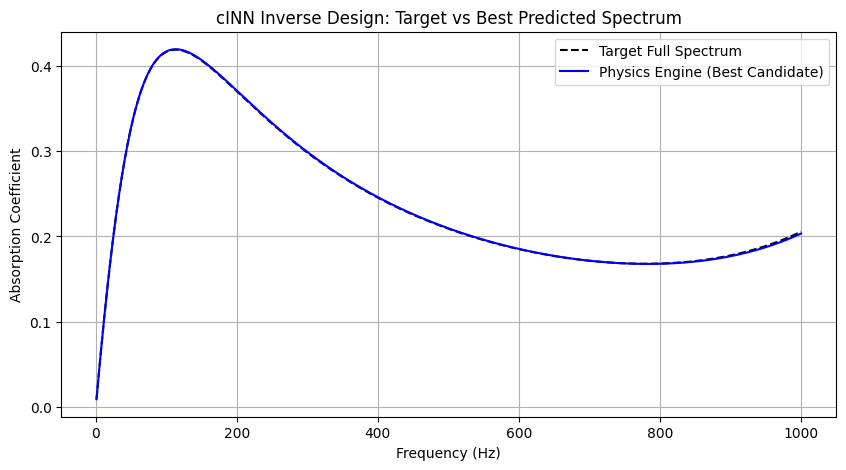

In [29]:
# %%
def inverse_design_cinn(target_spectrum, model, scaler, num_candidates=10):
    model.eval()

    target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
    z_random = torch.randn(num_candidates, 20).to(device)

    with torch.no_grad():
        generated_norm = model(z_random, target_tensor, rev=True)

    generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
    generated_params = validate_and_clip_parameters(generated_params)

    print(f"Evaluating {num_candidates} cINN generated candidates through physics engine...")
    simulated_spectra = batch_physics_evaluation(generated_params, batch_size=num_candidates)

    rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
    best_idx = np.argmin(rmses)

    return generated_params[best_idx], simulated_spectra[best_idx], rmses[best_idx]


# Execute test
test_target = Y_test[0]
best_params, best_pred_spectrum, rmse = inverse_design_cinn(test_target, model, scaler_params, num_candidates=10)

# Visualize result
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, 1001), test_target, label='Target Full Spectrum', color='black', linestyle='--')
plt.plot(np.arange(1, 1001), best_pred_spectrum, label='Physics Engine (Best Candidate)', color='blue')
plt.title('cINN Inverse Design: Target vs Best Predicted Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorption Coefficient')
plt.legend()
plt.grid(True)
plt.show()

# 6. Comprehensive evaluation on test set and validation of physics engine

In [30]:
# # ### 6. Comprehensive Evaluation on Test Set

# def calculate_spectral_metrics(target_spectrum, predicted_spectrum):
#     """Calculate comprehensive spectral evaluation metrics."""
#     epsilon = 1e-8
    
#     # Mean Squared Error
#     mse = np.mean((predicted_spectrum - target_spectrum) ** 2)
    
#     # Mean Absolute Error
#     mae = np.mean(np.abs(predicted_spectrum - target_spectrum))
    
#     # Root Mean Square Error
#     rmse = np.sqrt(mse)
    
#     # Relative Error (%)
#     relative_errors = np.abs(predicted_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon)
#     mean_relative_error = np.mean(relative_errors) * 100
    
#     # Maximum Absolute Error
#     max_error = np.max(np.abs(predicted_spectrum - target_spectrum))
    
#     # R-squared
#     ss_res = np.sum((target_spectrum - predicted_spectrum) ** 2)
#     ss_tot = np.sum((target_spectrum - np.mean(target_spectrum)) ** 2)
#     r2 = 1 - (ss_res / (ss_tot + epsilon))
    
#     return {
#         'mse': mse,
#         'mae': mae,
#         'rmse': rmse,
#         'relative_error': mean_relative_error,
#         'max_error': max_error,
#         'r2': r2
#     }


# def evaluate_test_set_cinn(model, scaler, X_test, Y_test, num_candidates=10, num_samples=None):
#     """
#     Comprehensive evaluation on test set using cINN.
    
#     Parameters
#     ----------
#     num_samples : int, optional
#         Number of samples to evaluate. If None, evaluates all samples.
#     """
#     model.eval()
    
#     # Limit samples if specified
#     if num_samples is not None:
#         eval_samples = min(num_samples, len(Y_test))
#     else:
#         eval_samples = len(Y_test)
    
#     results = {
#         'spectrum_mse': [],
#         'spectrum_mae': [],
#         'spectrum_rmse': [],
#         'spectrum_relative_error': [],
#         'spectrum_max_error': [],
#         'spectrum_r2': [],
#         'all_predictions': [],
#     }
    
#     print(f"\n{'='*70}")
#     print(f"EVALUATING TEST SET ({eval_samples:,} samples)")
#     print(f"{'='*70}")
    
#     for idx in range(eval_samples):
#         if (idx + 1) % 10 == 0 or idx == 0:
#             print(f"Processing sample {idx+1}/{eval_samples}...")
        
#         target_spectrum = Y_test[idx]
        
#         # Generate candidates using cINN
#         target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
#         z_random = torch.randn(num_candidates, 20).to(device)
        
#         with torch.no_grad():
#             generated_norm = model(z_random, target_tensor, rev=True)
        
#         generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
#         generated_params = validate_and_clip_parameters(generated_params)
        
#         # Physics evaluation
#         simulated_spectra = batch_physics_evaluation(generated_params)
        
#         # Find best candidate
#         rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
#         best_idx = np.argmin(rmses)
#         best_spectrum = simulated_spectra[best_idx]
        
#         # Calculate metrics
#         metrics = calculate_spectral_metrics(target_spectrum, best_spectrum)
        
#         results['spectrum_mse'].append(metrics['mse'])
#         results['spectrum_mae'].append(metrics['mae'])
#         results['spectrum_rmse'].append(metrics['rmse'])
#         results['spectrum_relative_error'].append(metrics['relative_error'])
#         results['spectrum_max_error'].append(metrics['max_error'])
#         results['spectrum_r2'].append(metrics['r2'])
#         results['all_predictions'].append((target_spectrum, best_spectrum, generated_params))
    
#     return results


# # ============================================================================
# # RUN EVALUATION (Change num_samples to None for full test set)
# # ============================================================================
# print("\n" + "="*70)
# print("COMPREHENSIVE TEST SET EVALUATION")
# print("="*70)

# # Evaluate on 100 samples (change to None for full test set)
# test_results = evaluate_test_set_cinn(
#     model, scaler_params, X_test, Y_test, 
#     num_candidates=10, 
#     num_samples=100  # Change to None for full evaluation
# )

# # ============================================================================
# # DETAILED RESULTS ANALYSIS
# # ============================================================================
# print("\n" + "="*80)
# print("COMPREHENSIVE TEST SET RESULTS")
# print("="*80)

# mse_errors = np.array(test_results['spectrum_mse'])
# mae_errors = np.array(test_results['spectrum_mae'])
# rmse_errors = np.array(test_results['spectrum_rmse'])
# rel_errors = np.array(test_results['spectrum_relative_error'])
# max_errors = np.array(test_results['spectrum_max_error'])
# r2_scores = np.array(test_results['spectrum_r2'])

# # Find best and worst samples
# best_sample_idx = np.argmin(mse_errors)
# worst_sample_idx = np.argmax(mse_errors)

# print(f"\n📊 Dataset Size: {len(mse_errors):,} test samples evaluated")

# # ============================================================================
# # 1. OVERALL PERFORMANCE
# # ============================================================================
# print(f"\n" + "="*80)
# print(f"1️⃣  OVERALL PERFORMANCE - TEST SET")
# print(f"="*80)

# print(f"\n📈 Spectral Mean Squared Error (MSE):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {mse_errors.mean():>24.8f} │")
# print(f"   │ Median:      {np.median(mse_errors):>24.8f} │")
# print(f"   │ Std Dev:     {mse_errors.std():>24.8f} │")
# print(f"   │ Min:         {mse_errors.min():>24.8f} │")
# print(f"   │ Max:         {mse_errors.max():>24.8f} │")
# print(f"   │ 25th %ile:   {np.percentile(mse_errors, 25):>24.8f} │")
# print(f"   │ 75th %ile:   {np.percentile(mse_errors, 75):>24.8f} │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📊 Spectral Mean Absolute Error (MAE):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {mae_errors.mean():>24.8f} │")
# print(f"   │ Median:      {np.median(mae_errors):>24.8f} │")
# print(f"   │ Std Dev:     {mae_errors.std():>24.8f} │")
# print(f"   │ Min:         {mae_errors.min():>24.8f} │")
# print(f"   │ Max:         {mae_errors.max():>24.8f} │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📉 Full-Curve Root Mean Square Error (RMSE):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {rmse_errors.mean():>24.8f} │")
# print(f"   │ Median:      {np.median(rmse_errors):>24.8f} │")
# print(f"   │ Std Dev:     {rmse_errors.std():>24.8f} │")
# print(f"   │ Min:         {rmse_errors.min():>24.8f} │")
# print(f"   │ Max:         {rmse_errors.max():>24.8f} │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📈 Spectral Relative Error (%):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {rel_errors.mean():>23.4f}% │")
# print(f"   │ Median:      {np.median(rel_errors):>23.4f}% │")
# print(f"   │ Std Dev:     {rel_errors.std():>23.4f}% │")
# print(f"   │ Min:         {rel_errors.min():>23.4f}% │")
# print(f"   │ Max:         {rel_errors.max():>23.4f}% │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📊 R-squared (R²) Coefficient:")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {r2_scores.mean():>24.6f} │")
# print(f"   │ Median:      {np.median(r2_scores):>24.6f} │")
# print(f"   │ Std Dev:     {r2_scores.std():>24.6f} │")
# print(f"   │ Min:         {r2_scores.min():>24.6f} │")
# print(f"   │ Max:         {r2_scores.max():>24.6f} │")
# print(f"   └─────────────────────────────────────────┘")

# # ============================================================================
# # 2. BEST AND WORST SAMPLE METRICS
# # ============================================================================
# target_best, predicted_best, _ = test_results['all_predictions'][best_sample_idx]
# target_worst, predicted_worst, _ = test_results['all_predictions'][worst_sample_idx]
# metrics_best = calculate_spectral_metrics(target_best, predicted_best)
# metrics_worst = calculate_spectral_metrics(target_worst, predicted_worst)

# print(f"\n" + "="*80)
# print(f"2️⃣  BEST PERFORMING SAMPLE (Lowest MSE) - Index: {best_sample_idx}")
# print(f"="*80)
# print(f"   │ MSE:              {metrics_best['mse']:>20.8f} │")
# print(f"   │ MAE:              {metrics_best['mae']:>20.8f} │")
# print(f"   │ RMSE:             {metrics_best['rmse']:>20.8f} │")
# print(f"   │ Relative Error:   {metrics_best['relative_error']:>19.4f}% │")
# print(f"   │ R²:               {metrics_best['r2']:>20.6f} │")

# print(f"\n" + "="*80)
# print(f"3️⃣  WORST PERFORMING SAMPLE (Highest MSE) - Index: {worst_sample_idx}")
# print(f"="*80)
# print(f"   │ MSE:              {metrics_worst['mse']:>20.8f} │")
# print(f"   │ MAE:              {metrics_worst['mae']:>20.8f} │")
# print(f"   │ RMSE:             {metrics_worst['rmse']:>20.8f} │")
# print(f"   │ Relative Error:   {metrics_worst['relative_error']:>19.4f}% │")
# print(f"   │ R²:               {metrics_worst['r2']:>20.6f} │")

# # ============================================================================
# # 3. ERROR DISTRIBUTION ANALYSIS
# # ============================================================================
# print(f"\n" + "="*80)
# print(f"4️⃣  ERROR DISTRIBUTION ANALYSIS")
# print(f"="*80)

# excellent = np.sum(mse_errors < 0.001)
# good = np.sum((mse_errors >= 0.001) & (mse_errors < 0.01))
# fair = np.sum((mse_errors >= 0.01) & (mse_errors < 0.1))
# poor = np.sum(mse_errors >= 0.1)

# print(f"\n   MSE-based Quality Distribution:")
# print(f"   ┌───────────────────────────────────────────────────────┐")
# print(f"   │ Excellent (MSE < 0.001):   {excellent:>6d} ({100*excellent/len(mse_errors):>5.1f}%)  │")
# print(f"   │ Good (0.001 ≤ MSE < 0.01): {good:>6d} ({100*good/len(mse_errors):>5.1f}%)  │")
# print(f"   │ Fair (0.01 ≤ MSE < 0.1):   {fair:>6d} ({100*fair/len(mse_errors):>5.1f}%)  │")
# print(f"   │ Poor (MSE ≥ 0.1):          {poor:>6d} ({100*poor/len(mse_errors):>5.1f}%)  │")
# print(f"   └───────────────────────────────────────────────────────┘")

# # ============================================================================
# # 4. VISUALIZATION: BEST AND WORST PREDICTIONS
# # ============================================================================
# frequencies = np.arange(1, 1001)

# fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# # ----- BEST PREDICTION -----
# # Main spectrum comparison
# ax = axes[0, 0]
# ax.plot(frequencies, target_best, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
# ax.plot(frequencies, predicted_best, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
# ax.fill_between(frequencies, target_best, predicted_best, alpha=0.2, color='orange')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absorption Coefficient', fontsize=11)
# ax.set_title(f'BEST Prediction (Sample {best_sample_idx})\nMSE={metrics_best["mse"]:.6f}, R²={metrics_best["r2"]:.4f}', 
#              fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# ax.set_ylim([0, 1.05])

# # Point-wise error
# ax = axes[0, 1]
# abs_error_best = np.abs(predicted_best - target_best)
# ax.plot(frequencies, abs_error_best, 'g-', linewidth=1.5)
# ax.fill_between(frequencies, 0, abs_error_best, alpha=0.3, color='green')
# ax.axhline(y=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_best):.6f}')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absolute Error', fontsize=11)
# ax.set_title('BEST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # Error histogram
# ax = axes[0, 2]
# ax.hist(abs_error_best, bins=50, color='green', alpha=0.7, edgecolor='black')
# ax.axvline(x=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_best):.6f}')
# ax.set_xlabel('Absolute Error', fontsize=11)
# ax.set_ylabel('Frequency Count', fontsize=11)
# ax.set_title('BEST: Error Distribution', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # ----- WORST PREDICTION -----
# # Main spectrum comparison
# ax = axes[1, 0]
# ax.plot(frequencies, target_worst, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
# ax.plot(frequencies, predicted_worst, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
# ax.fill_between(frequencies, target_worst, predicted_worst, alpha=0.2, color='orange')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absorption Coefficient', fontsize=11)
# ax.set_title(f'WORST Prediction (Sample {worst_sample_idx})\nMSE={metrics_worst["mse"]:.6f}, R²={metrics_worst["r2"]:.4f}', 
#              fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# ax.set_ylim([0, 1.05])

# # Point-wise error
# ax = axes[1, 1]
# abs_error_worst = np.abs(predicted_worst - target_worst)
# ax.plot(frequencies, abs_error_worst, 'g-', linewidth=1.5)
# ax.fill_between(frequencies, 0, abs_error_worst, alpha=0.3, color='green')
# ax.axhline(y=np.mean(abs_error_worst), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_worst):.6f}')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absolute Error', fontsize=11)
# ax.set_title('WORST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # Error histogram
# ax = axes[1, 2]
# ax.hist(abs_error_worst, bins=50, color='red', alpha=0.7, edgecolor='black')
# ax.axvline(x=np.mean(abs_error_worst), color='darkred', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_worst):.6f}')
# ax.set_xlabel('Absolute Error', fontsize=11)
# ax.set_ylabel('Frequency Count', fontsize=11)
# ax.set_title('WORST: Error Distribution', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# plt.suptitle('cINN Inverse Design: Best vs Worst Predictions Comparison', 
#              fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.savefig('cinn_best_worst_predictions.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"\n✅ Plot saved to: cinn_best_worst_predictions.png")

# # ============================================================================
# # 5. ERROR DISTRIBUTIONS ACROSS TEST SET
# # ============================================================================
# fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# # MSE Distribution
# ax = axes[0, 0]
# ax.hist(mse_errors, bins=50, color='blue', alpha=0.7, edgecolor='black')
# ax.axvline(x=mse_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {mse_errors.mean():.6f}')
# ax.set_xlabel('MSE', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('MSE Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # MAE Distribution
# ax = axes[0, 1]
# ax.hist(mae_errors, bins=50, color='green', alpha=0.7, edgecolor='black')
# ax.axvline(x=mae_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {mae_errors.mean():.6f}')
# ax.set_xlabel('MAE', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('MAE Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # RMSE Distribution
# ax = axes[0, 2]
# ax.hist(rmse_errors, bins=50, color='orange', alpha=0.7, edgecolor='black')
# ax.axvline(x=rmse_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {rmse_errors.mean():.6f}')
# ax.set_xlabel('RMSE', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('RMSE Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # Relative Error Distribution
# ax = axes[1, 0]
# ax.hist(rel_errors, bins=50, color='purple', alpha=0.7, edgecolor='black')
# ax.axvline(x=rel_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {rel_errors.mean():.2f}%')
# ax.set_xlabel('Relative Error (%)', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('Relative Error Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # R² Distribution
# ax = axes[1, 1]
# ax.hist(r2_scores, bins=50, color='cyan', alpha=0.7, edgecolor='black')
# ax.axvline(x=r2_scores.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {r2_scores.mean():.4f}')
# ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('R² Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # Quality summary bar chart
# ax = axes[1, 2]
# categories = ['Excellent\n(<0.001)', 'Good\n(0.001-0.01)', 'Fair\n(0.01-0.1)', 'Poor\n(≥0.1)']
# counts = [excellent, good, fair, poor]
# colors = ['green', 'lightgreen', 'orange', 'red']
# ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
# ax.set_ylabel('Sample Count', fontsize=12, fontweight='bold')
# ax.set_title('MSE Quality Distribution', fontsize=13, fontweight='bold')
# ax.grid(True, alpha=0.3, axis='y')
# for i, (count, pct) in enumerate(zip(counts, [100*c/len(mse_errors) for c in counts])):
#     ax.text(i, count + 1, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

# plt.suptitle('cINN Test Set Error Distribution Analysis', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.savefig('cinn_error_distributions.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"✅ Error distributions saved to: cinn_error_distributions.png")

# # ============================================================================
# # 6. FINAL SUMMARY
# # ============================================================================
# print("\n" + "="*80)
# print("📊 FINAL PERFORMANCE SUMMARY")
# print("="*80)

# overall_quality = "EXCELLENT" if mse_errors.mean() < 0.001 else \
#                   "GOOD" if mse_errors.mean() < 0.01 else \
#                   "FAIR" if mse_errors.mean() < 0.1 else "NEEDS IMPROVEMENT"

# print(f"\n   🎯 Overall Model Quality: {overall_quality}")
# print(f"   📊 Samples Evaluated: {len(mse_errors):,}")
# print(f"   ✅ Samples with MSE < 0.01: {excellent + good:,} ({100*(excellent+good)/len(mse_errors):.1f}%)")
# print(f"   ✅ Samples with R² > 0.9: {np.sum(r2_scores > 0.9):,} ({100*np.sum(r2_scores > 0.9)/len(r2_scores):.1f}%)")

# print("\n" + "="*80)
# print("✅ COMPREHENSIVE EVALUATION COMPLETE")
# print("="*80)

In [47]:
# # ### 6. Comprehensive Evaluation on Test Set

# def calculate_spectral_metrics(target_spectrum, predicted_spectrum):
#     """Calculate comprehensive spectral evaluation metrics."""
#     epsilon = 1e-8
    
#     # Mean Squared Error
#     mse = np.mean((predicted_spectrum - target_spectrum) ** 2)
    
#     # Mean Absolute Error
#     mae = np.mean(np.abs(predicted_spectrum - target_spectrum))
    
#     # Root Mean Square Error
#     rmse = np.sqrt(mse)
    
#     # Relative Error (%)
#     relative_errors = np.abs(predicted_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon)
#     mean_relative_error = np.mean(relative_errors) * 100
    
#     # Maximum Absolute Error
#     max_error = np.max(np.abs(predicted_spectrum - target_spectrum))
    
#     # R-squared
#     ss_res = np.sum((target_spectrum - predicted_spectrum) ** 2)
#     ss_tot = np.sum((target_spectrum - np.mean(target_spectrum)) ** 2)
#     r2 = 1 - (ss_res / (ss_tot + epsilon))
    
#     return {
#         'mse': mse,
#         'mae': mae,
#         'rmse': rmse,
#         'relative_error': mean_relative_error,
#         'max_error': max_error,
#         'r2': r2
#     }


# def evaluate_test_set_cinn(model, scaler, X_test, Y_test, num_candidates=20, num_samples=None):
#     """
#     Comprehensive evaluation on test set using cINN.
    
#     Parameters
#     ----------
#     num_samples : int, optional
#         Number of samples to evaluate. If None, evaluates all samples.
#     """
#     model.eval()
    
#     # Limit samples if specified
#     if num_samples is not None:
#         eval_samples = min(num_samples, len(Y_test))
#     else:
#         eval_samples = len(Y_test)
    
#     results = {
#         'spectrum_mse': [],
#         'spectrum_mae': [],
#         'spectrum_rmse': [],
#         'spectrum_relative_error': [],
#         'spectrum_max_error': [],
#         'spectrum_r2': [],
#         'all_predictions': [],
#     }
    
#     print(f"\n{'='*70}")
#     print(f"EVALUATING TEST SET ({eval_samples:,} samples)")
#     print(f"{'='*70}")
    
#     for idx in range(eval_samples):
#         # CHANGED: Now only prints on the 1st sample, and then every 1000th sample
#         if (idx + 1) % 1000 == 0 or idx == 0:
#             print(f"Processing sample {idx+1}/{eval_samples}...")
        
#         target_spectrum = Y_test[idx]
        
#         # Generate candidates using cINN
#         target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
#         z_random = torch.randn(num_candidates, 20).to(device)
        
#         with torch.no_grad():
#             generated_norm = model(z_random, target_tensor, rev=True)
        
#         generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
#         generated_params = validate_and_clip_parameters(generated_params)
        
#         # Physics evaluation
#         simulated_spectra = batch_physics_evaluation(generated_params)
        
#         # Find best candidate
#         rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
#         best_idx = np.argmin(rmses)
#         best_spectrum = simulated_spectra[best_idx]
        
#         # Calculate metrics
#         metrics = calculate_spectral_metrics(target_spectrum, best_spectrum)
        
#         results['spectrum_mse'].append(metrics['mse'])
#         results['spectrum_mae'].append(metrics['mae'])
#         results['spectrum_rmse'].append(metrics['rmse'])
#         results['spectrum_relative_error'].append(metrics['relative_error'])
#         results['spectrum_max_error'].append(metrics['max_error'])
#         results['spectrum_r2'].append(metrics['r2'])
#         results['all_predictions'].append((target_spectrum, best_spectrum, generated_params))
    
#     return results


# # ============================================================================
# # RUN EVALUATION (Change num_samples to None for full test set)
# # ============================================================================
# print("\n" + "="*70)
# print("COMPREHENSIVE TEST SET EVALUATION")
# print("="*70)

# # Evaluate on 100 samples (change to None for full test set)
# test_results = evaluate_test_set_cinn(
#     model, scaler_params, X_test, Y_test, 
#     num_candidates=10, 
#     num_samples=None  # Change to None for full evaluation
# )

# # ============================================================================
# # DETAILED RESULTS ANALYSIS
# # ============================================================================
# print("\n" + "="*80)
# print("COMPREHENSIVE TEST SET RESULTS")
# print("="*80)

# mse_errors = np.array(test_results['spectrum_mse'])
# mae_errors = np.array(test_results['spectrum_mae'])
# rmse_errors = np.array(test_results['spectrum_rmse'])
# rel_errors = np.array(test_results['spectrum_relative_error'])
# max_errors = np.array(test_results['spectrum_max_error'])
# r2_scores = np.array(test_results['spectrum_r2'])

# # Find best and worst samples
# best_sample_idx = np.argmin(mse_errors)
# worst_sample_idx = np.argmax(mse_errors)

# print(f"\n📊 Dataset Size: {len(mse_errors):,} test samples evaluated")

# # ============================================================================
# # 1. OVERALL PERFORMANCE
# # ============================================================================
# print(f"\n" + "="*80)
# print(f"1️⃣  OVERALL PERFORMANCE - TEST SET")
# print(f"="*80)

# print(f"\n📈 Spectral Mean Squared Error (MSE):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {mse_errors.mean():>24.8f} │")
# print(f"   │ Median:      {np.median(mse_errors):>24.8f} │")
# print(f"   │ Std Dev:     {mse_errors.std():>24.8f} │")
# print(f"   │ Min:         {mse_errors.min():>24.8f} │")
# print(f"   │ Max:         {mse_errors.max():>24.8f} │")
# print(f"   │ 25th %ile:   {np.percentile(mse_errors, 25):>24.8f} │")
# print(f"   │ 75th %ile:   {np.percentile(mse_errors, 75):>24.8f} │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📊 Spectral Mean Absolute Error (MAE):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {mae_errors.mean():>24.8f} │")
# print(f"   │ Median:      {np.median(mae_errors):>24.8f} │")
# print(f"   │ Std Dev:     {mae_errors.std():>24.8f} │")
# print(f"   │ Min:         {mae_errors.min():>24.8f} │")
# print(f"   │ Max:         {mae_errors.max():>24.8f} │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📉 Full-Curve Root Mean Square Error (RMSE):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {rmse_errors.mean():>24.8f} │")
# print(f"   │ Median:      {np.median(rmse_errors):>24.8f} │")
# print(f"   │ Std Dev:     {rmse_errors.std():>24.8f} │")
# print(f"   │ Min:         {rmse_errors.min():>24.8f} │")
# print(f"   │ Max:         {rmse_errors.max():>24.8f} │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📈 Spectral Relative Error (%):")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {rel_errors.mean():>23.4f}% │")
# print(f"   │ Median:      {np.median(rel_errors):>23.4f}% │")
# print(f"   │ Std Dev:     {rel_errors.std():>23.4f}% │")
# print(f"   │ Min:         {rel_errors.min():>23.4f}% │")
# print(f"   │ Max:         {rel_errors.max():>23.4f}% │")
# print(f"   └─────────────────────────────────────────┘")

# print(f"\n📊 R-squared (R²) Coefficient:")
# print(f"   ┌─────────────────────────────────────────┐")
# print(f"   │ Mean:        {r2_scores.mean():>24.6f} │")
# print(f"   │ Median:      {np.median(r2_scores):>24.6f} │")
# print(f"   │ Std Dev:     {r2_scores.std():>24.6f} │")
# print(f"   │ Min:         {r2_scores.min():>24.6f} │")
# print(f"   │ Max:         {r2_scores.max():>24.6f} │")
# print(f"   └─────────────────────────────────────────┘")

# # ============================================================================
# # 2. BEST AND WORST SAMPLE METRICS
# # ============================================================================
# target_best, predicted_best, _ = test_results['all_predictions'][best_sample_idx]
# target_worst, predicted_worst, _ = test_results['all_predictions'][worst_sample_idx]
# metrics_best = calculate_spectral_metrics(target_best, predicted_best)
# metrics_worst = calculate_spectral_metrics(target_worst, predicted_worst)

# print(f"\n" + "="*80)
# print(f"2️⃣  BEST PERFORMING SAMPLE (Lowest MSE) - Index: {best_sample_idx}")
# print(f"="*80)
# print(f"   │ MSE:              {metrics_best['mse']:>20.8f} │")
# print(f"   │ MAE:              {metrics_best['mae']:>20.8f} │")
# print(f"   │ RMSE:             {metrics_best['rmse']:>20.8f} │")
# print(f"   │ Relative Error:   {metrics_best['relative_error']:>19.4f}% │")
# print(f"   │ R²:               {metrics_best['r2']:>20.6f} │")

# print(f"\n" + "="*80)
# print(f"3️⃣  WORST PERFORMING SAMPLE (Highest MSE) - Index: {worst_sample_idx}")
# print(f"="*80)
# print(f"   │ MSE:              {metrics_worst['mse']:>20.8f} │")
# print(f"   │ MAE:              {metrics_worst['mae']:>20.8f} │")
# print(f"   │ RMSE:             {metrics_worst['rmse']:>20.8f} │")
# print(f"   │ Relative Error:   {metrics_worst['relative_error']:>19.4f}% │")
# print(f"   │ R²:               {metrics_worst['r2']:>20.6f} │")

# # ============================================================================
# # 3. ERROR DISTRIBUTION ANALYSIS
# # ============================================================================
# print(f"\n" + "="*80)
# print(f"4️⃣  ERROR DISTRIBUTION ANALYSIS")
# print(f"="*80)

# excellent = np.sum(mse_errors < 0.001)
# good = np.sum((mse_errors >= 0.001) & (mse_errors < 0.01))
# fair = np.sum((mse_errors >= 0.01) & (mse_errors < 0.1))
# poor = np.sum(mse_errors >= 0.1)

# print(f"\n   MSE-based Quality Distribution:")
# print(f"   ┌───────────────────────────────────────────────────────┐")
# print(f"   │ Excellent (MSE < 0.001):   {excellent:>6d} ({100*excellent/len(mse_errors):>5.1f}%)  │")
# print(f"   │ Good (0.001 ≤ MSE < 0.01): {good:>6d} ({100*good/len(mse_errors):>5.1f}%)  │")
# print(f"   │ Fair (0.01 ≤ MSE < 0.1):   {fair:>6d} ({100*fair/len(mse_errors):>5.1f}%)  │")
# print(f"   │ Poor (MSE ≥ 0.1):          {poor:>6d} ({100*poor/len(mse_errors):>5.1f}%)  │")
# print(f"   └───────────────────────────────────────────────────────┘")

# # ============================================================================
# # 4. VISUALIZATION: BEST AND WORST PREDICTIONS
# # ============================================================================
# frequencies = np.arange(1, 1001)

# fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# # ----- BEST PREDICTION -----
# # Main spectrum comparison
# ax = axes[0, 0]
# ax.plot(frequencies, target_best, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
# ax.plot(frequencies, predicted_best, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
# ax.fill_between(frequencies, target_best, predicted_best, alpha=0.2, color='orange')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absorption Coefficient', fontsize=11)
# ax.set_title(f'BEST Prediction (Sample {best_sample_idx})\nMSE={metrics_best["mse"]:.6f}, R²={metrics_best["r2"]:.4f}', 
#              fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# ax.set_ylim([0, 1.05])

# # Point-wise error
# ax = axes[0, 1]
# abs_error_best = np.abs(predicted_best - target_best)
# ax.plot(frequencies, abs_error_best, 'g-', linewidth=1.5)
# ax.fill_between(frequencies, 0, abs_error_best, alpha=0.3, color='green')
# ax.axhline(y=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_best):.6f}')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absolute Error', fontsize=11)
# ax.set_title('BEST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # Error histogram
# ax = axes[0, 2]
# ax.hist(abs_error_best, bins=50, color='green', alpha=0.7, edgecolor='black')
# ax.axvline(x=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_best):.6f}')
# ax.set_xlabel('Absolute Error', fontsize=11)
# ax.set_ylabel('Frequency Count', fontsize=11)
# ax.set_title('BEST: Error Distribution', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # ----- WORST PREDICTION -----
# # Main spectrum comparison
# ax = axes[1, 0]
# ax.plot(frequencies, target_worst, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
# ax.plot(frequencies, predicted_worst, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
# ax.fill_between(frequencies, target_worst, predicted_worst, alpha=0.2, color='orange')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absorption Coefficient', fontsize=11)
# ax.set_title(f'WORST Prediction (Sample {worst_sample_idx})\nMSE={metrics_worst["mse"]:.6f}, R²={metrics_worst["r2"]:.4f}', 
#              fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# ax.set_ylim([0, 1.05])

# # Point-wise error
# ax = axes[1, 1]
# abs_error_worst = np.abs(predicted_worst - target_worst)
# ax.plot(frequencies, abs_error_worst, 'g-', linewidth=1.5)
# ax.fill_between(frequencies, 0, abs_error_worst, alpha=0.3, color='green')
# ax.axhline(y=np.mean(abs_error_worst), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_worst):.6f}')
# ax.set_xlabel('Frequency (Hz)', fontsize=11)
# ax.set_ylabel('Absolute Error', fontsize=11)
# ax.set_title('WORST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # Error histogram
# ax = axes[1, 2]
# ax.hist(abs_error_worst, bins=50, color='red', alpha=0.7, edgecolor='black')
# ax.axvline(x=np.mean(abs_error_worst), color='darkred', linestyle='--', linewidth=2, 
#            label=f'Mean: {np.mean(abs_error_worst):.6f}')
# ax.set_xlabel('Absolute Error', fontsize=11)
# ax.set_ylabel('Frequency Count', fontsize=11)
# ax.set_title('WORST: Error Distribution', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# plt.suptitle('cINN Inverse Design: Best vs Worst Predictions Comparison', 
#              fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.savefig('cinn_best_worst_predictions.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"\n✅ Plot saved to: cinn_best_worst_predictions.png")

# # ============================================================================
# # 5. ERROR DISTRIBUTIONS ACROSS TEST SET
# # ============================================================================
# fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# # MSE Distribution
# ax = axes[0, 0]
# ax.hist(mse_errors, bins=50, color='blue', alpha=0.7, edgecolor='black')
# ax.axvline(x=mse_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {mse_errors.mean():.6f}')
# ax.set_xlabel('MSE', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('MSE Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # MAE Distribution
# ax = axes[0, 1]
# ax.hist(mae_errors, bins=50, color='green', alpha=0.7, edgecolor='black')
# ax.axvline(x=mae_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {mae_errors.mean():.6f}')
# ax.set_xlabel('MAE', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('MAE Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # RMSE Distribution
# ax = axes[0, 2]
# ax.hist(rmse_errors, bins=50, color='orange', alpha=0.7, edgecolor='black')
# ax.axvline(x=rmse_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {rmse_errors.mean():.6f}')
# ax.set_xlabel('RMSE', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('RMSE Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # Relative Error Distribution
# ax = axes[1, 0]
# ax.hist(rel_errors, bins=50, color='purple', alpha=0.7, edgecolor='black')
# ax.axvline(x=rel_errors.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {rel_errors.mean():.2f}%')
# ax.set_xlabel('Relative Error (%)', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('Relative Error Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # R² Distribution
# ax = axes[1, 1]
# ax.hist(r2_scores, bins=50, color='cyan', alpha=0.7, edgecolor='black')
# ax.axvline(x=r2_scores.mean(), color='r', linestyle='--', linewidth=2, 
#            label=f'Mean: {r2_scores.mean():.4f}')
# ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('R² Distribution', fontsize=13, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # Quality summary bar chart
# ax = axes[1, 2]
# categories = ['Excellent\n(<0.001)', 'Good\n(0.001-0.01)', 'Fair\n(0.01-0.1)', 'Poor\n(≥0.1)']
# counts = [excellent, good, fair, poor]
# colors = ['green', 'lightgreen', 'orange', 'red']
# ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
# ax.set_ylabel('Sample Count', fontsize=12, fontweight='bold')
# ax.set_title('MSE Quality Distribution', fontsize=13, fontweight='bold')
# ax.grid(True, alpha=0.3, axis='y')
# for i, (count, pct) in enumerate(zip(counts, [100*c/len(mse_errors) for c in counts])):
#     ax.text(i, count + 1, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

# plt.suptitle('cINN Test Set Error Distribution Analysis', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.savefig('cinn_error_distributions.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"✅ Error distributions saved to: cinn_error_distributions.png")

# # ============================================================================
# # 6. FINAL SUMMARY
# # ============================================================================
# print("\n" + "="*80)
# print("📊 FINAL PERFORMANCE SUMMARY")
# print("="*80)

# overall_quality = "EXCELLENT" if mse_errors.mean() < 0.001 else \
#                   "GOOD" if mse_errors.mean() < 0.01 else \
#                   "FAIR" if mse_errors.mean() < 0.1 else "NEEDS IMPROVEMENT"

# print(f"\n   🎯 Overall Model Quality: {overall_quality}")
# print(f"   📊 Samples Evaluated: {len(mse_errors):,}")
# print(f"   ✅ Samples with MSE < 0.01: {excellent + good:,} ({100*(excellent+good)/len(mse_errors):.1f}%)")
# print(f"   ✅ Samples with R² > 0.9: {np.sum(r2_scores > 0.9):,} ({100*np.sum(r2_scores > 0.9)/len(r2_scores):.1f}%)")

# print("\n" + "="*80)
# print("✅ COMPREHENSIVE EVALUATION COMPLETE")
# print("="*80)


COMPREHENSIVE TEST SET EVALUATION

EVALUATING TEST SET (10,000 samples)
Processing sample 1/10000...
Processing sample 1000/10000...
Processing sample 2000/10000...
Processing sample 3000/10000...
Processing sample 4000/10000...
Processing sample 5000/10000...
Processing sample 6000/10000...
Processing sample 7000/10000...
Processing sample 8000/10000...
Processing sample 9000/10000...
Processing sample 10000/10000...

COMPREHENSIVE TEST SET RESULTS

📊 Dataset Size: 10,000 test samples evaluated

1️⃣  OVERALL PERFORMANCE - TEST SET

📈 Spectral Mean Squared Error (MSE):
   ┌─────────────────────────────────────────┐
   │ Mean:                      0.00006769 │
   │ Median:                    0.00000057 │
   │ Std Dev:                   0.00070220 │
   │ Min:                       0.00000000 │
   │ Max:                       0.03711246 │
   └─────────────────────────────────────────┘

📊 Spectral Mean Absolute Error (MAE):
   ┌─────────────────────────────────────────┐
   │ Mean:        

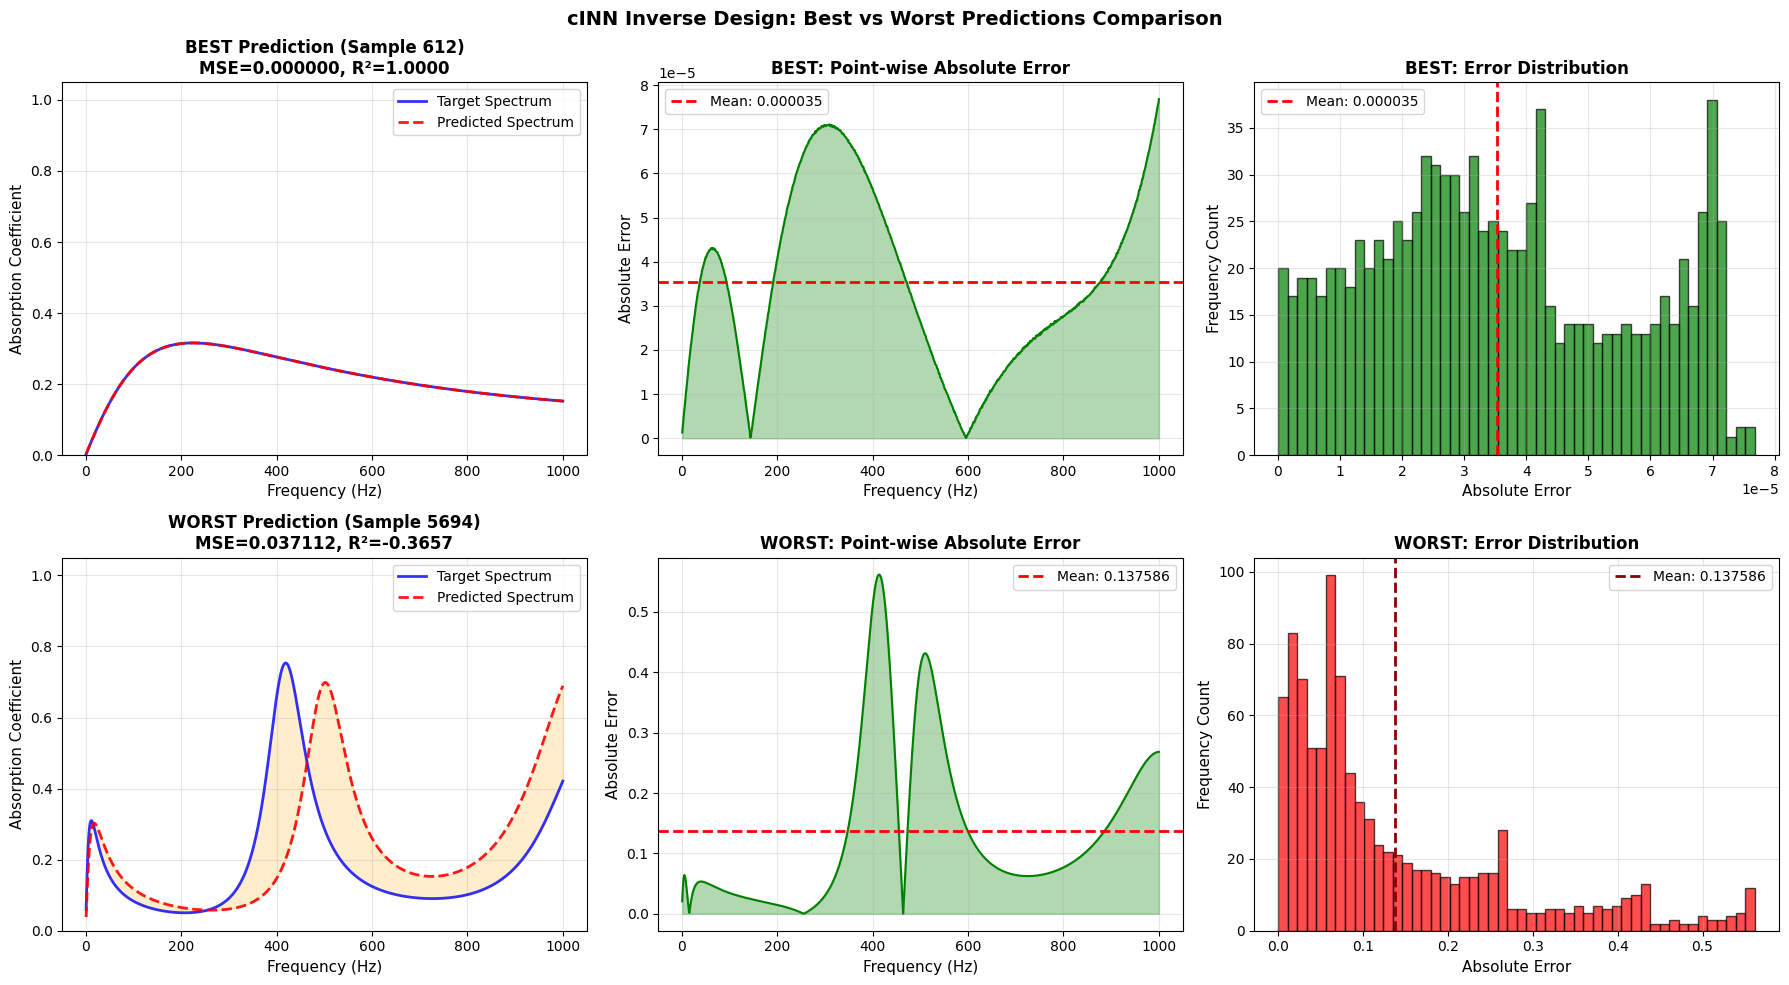

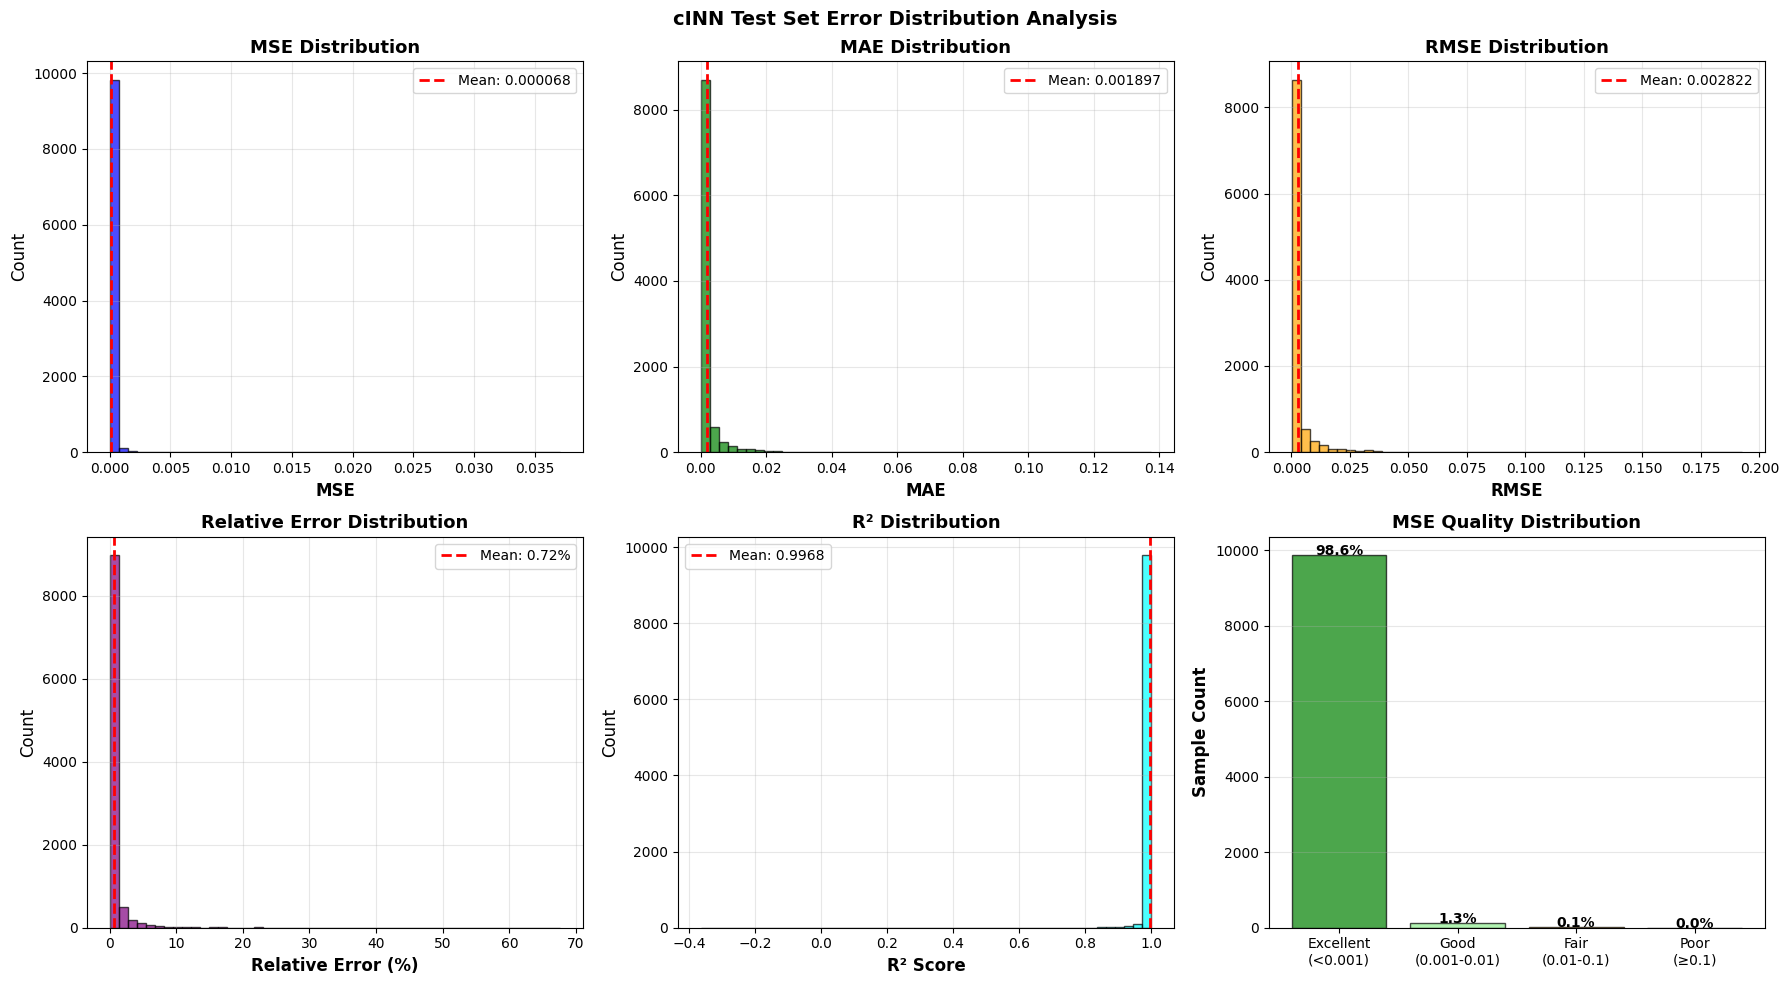


5️⃣  FREQUENCY-WISE RELATIVE ERROR ANALYSIS

📊 Frequency-wise Statistics (Averaged across 10000 test samples):
   ┌─────────────────────────────────────────────────┐
   │ Overall Mean Relative Error:          0.7214% │
   │ Overall Median Relative Error:        0.5217% │
   │ Overall Std Dev:                      2.7242% │
   │ Min Frequency Error:                  0.3163% │
   │ Max Frequency Error:                  1.9920% │
   └─────────────────────────────────────────────────┘

🔍 Frequency Ranges with Highest Errors:
   Top 10% error frequencies (>1.18%):
   ├─  901 - 1000 Hz  (Avg:   1.51%)

📈 Generating frequency-wise error visualization...


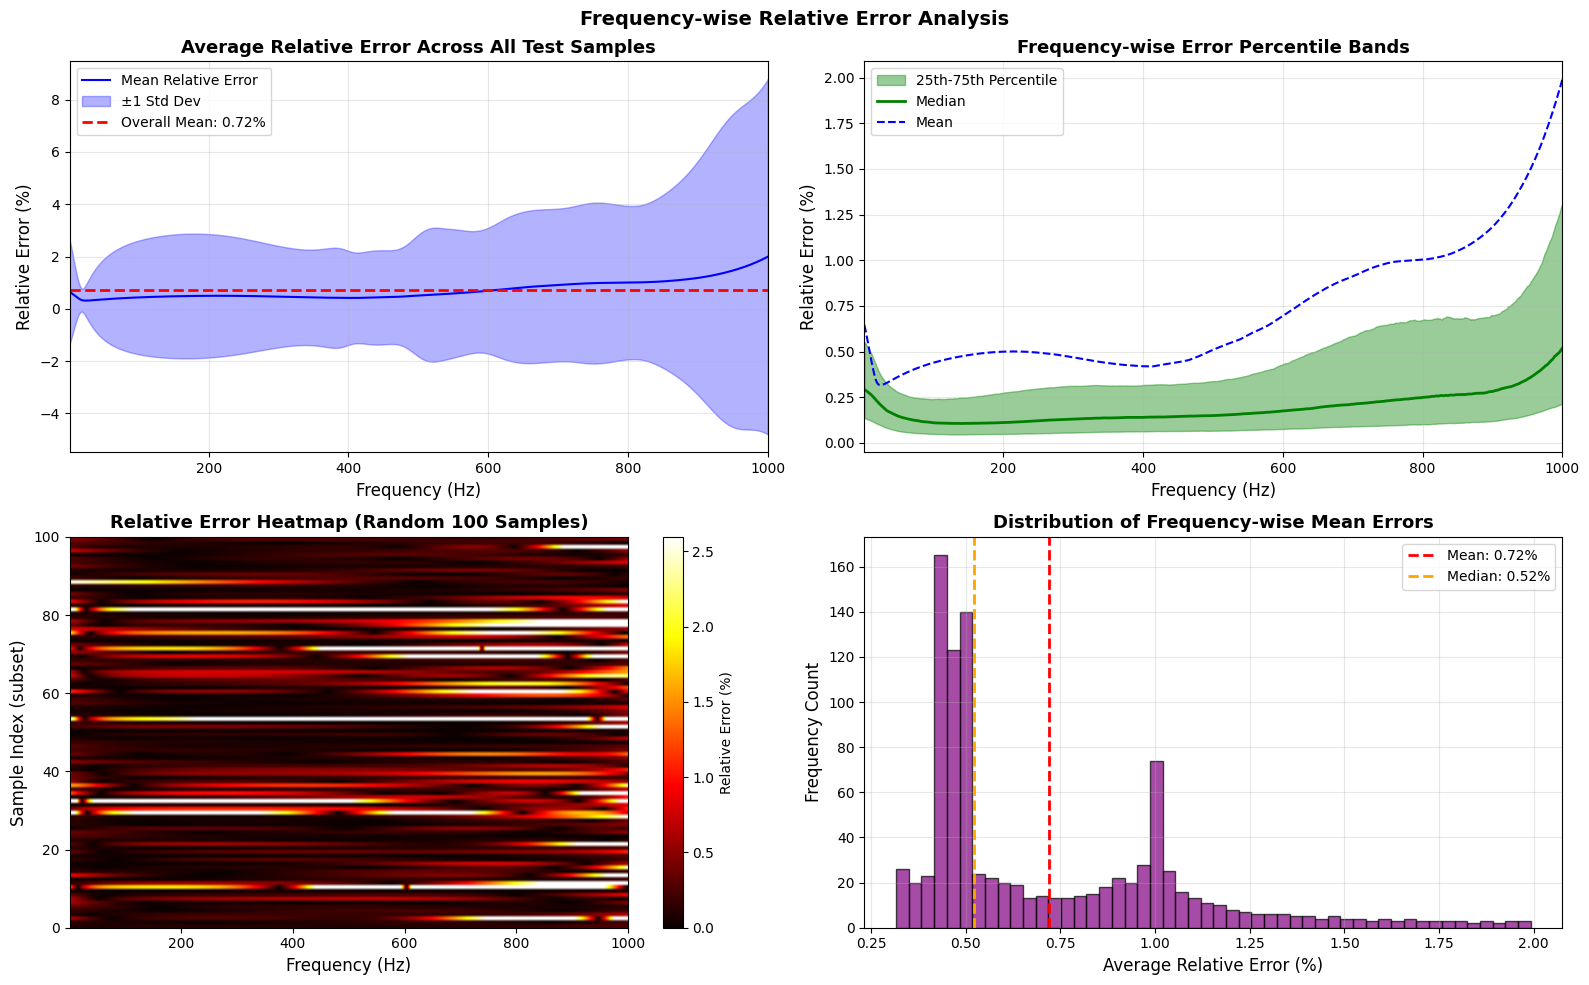


6️⃣  PHYSICS ENGINE VALIDATION (vs Theoretical Model)

📊 Validating physics engine on 100 test predictions...
   Validating sample 20/100...
   Validating sample 40/100...
   Validating sample 60/100...
   Validating sample 80/100...
   Validating sample 100/100...

PHYSICS ENGINE vs THEORETICAL MODEL VALIDATION

📊 Mean Absolute Error (MAE):
   ┌─────────────────────────────────────────┐
   │ Mean:                    0.0000000970 │
   │ Median:                  0.0000000954 │
   │ Min:                     0.0000000713 │
   │ Max:                     0.0000002060 │
   └─────────────────────────────────────────┘

📊 Maximum Point-wise Error:
   ┌─────────────────────────────────────────┐
   │ Mean:                    0.0000004116 │
   │ Max:                     0.0000012083 │
   └─────────────────────────────────────────┘

🔍 VALIDATION RESULT: ✅ VERY GOOD - Negligible differences
   Average MAE: 9.70e-08


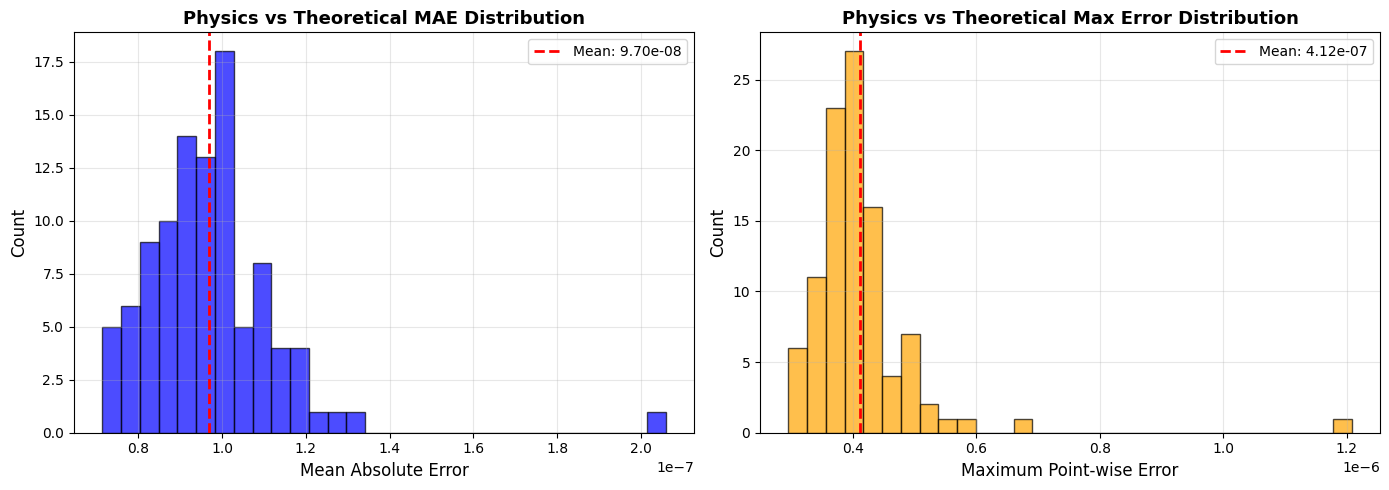


📊 FINAL PERFORMANCE SUMMARY

   🎯 Overall Model Quality: EXCELLENT
   📊 Samples Evaluated: 10,000
   ✅ Samples with MSE < 0.01: 9,991 (99.9%)
   ✅ Samples with R² > 0.9: 9,942 (99.4%)
   📈 Average Frequency-wise Error: 0.72%
   🔬 Physics Engine Validation: Negligible differences

✅ COMPREHENSIVE EVALUATION COMPLETE


In [46]:
# ### 6. Comprehensive Evaluation on Test Set

def calculate_spectral_metrics(target_spectrum, predicted_spectrum):
    """Calculate comprehensive spectral evaluation metrics."""
    epsilon = 1e-8
    
    mse = np.mean((predicted_spectrum - target_spectrum) ** 2)
    mae = np.mean(np.abs(predicted_spectrum - target_spectrum))
    rmse = np.sqrt(mse)
    
    relative_errors = np.abs(predicted_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon)
    mean_relative_error = np.mean(relative_errors) * 100
    
    max_error = np.max(np.abs(predicted_spectrum - target_spectrum))
    
    ss_res = np.sum((target_spectrum - predicted_spectrum) ** 2)
    ss_tot = np.sum((target_spectrum - np.mean(target_spectrum)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + epsilon))
    
    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'relative_error': mean_relative_error,
        'max_error': max_error,
        'r2': r2
    }


def evaluate_test_set_cinn(model, scaler, X_test, Y_test, num_candidates=10, num_samples=None):
    """Comprehensive evaluation on test set using cINN."""
    model.eval()
    
    if num_samples is not None:
        eval_samples = min(num_samples, len(Y_test))
    else:
        eval_samples = len(Y_test)
    
    results = {
        'spectrum_mse': [],
        'spectrum_mae': [],
        'spectrum_rmse': [],
        'spectrum_relative_error': [],
        'spectrum_max_error': [],
        'spectrum_r2': [],
        'all_predictions': [],
        'frequency_wise_errors': [],  # NEW: Store per-frequency errors
    }
    
    print(f"\n{'='*70}")
    print(f"EVALUATING TEST SET ({eval_samples:,} samples)")
    print(f"{'='*70}")
    
    for idx in range(eval_samples):
        if (idx + 1) % 1000 == 0 or idx == 0:
            print(f"Processing sample {idx+1}/{eval_samples}...")
        
        target_spectrum = Y_test[idx]
        
        target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
        z_random = torch.randn(num_candidates, 20).to(device)
        
        with torch.no_grad():
            generated_norm = model(z_random, target_tensor, rev=True)
        
        generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
        generated_params = validate_and_clip_parameters(generated_params)
        
        simulated_spectra = batch_physics_evaluation(generated_params)
        
        rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
        best_idx = np.argmin(rmses)
        best_spectrum = simulated_spectra[best_idx]
        
        metrics = calculate_spectral_metrics(target_spectrum, best_spectrum)
        
        results['spectrum_mse'].append(metrics['mse'])
        results['spectrum_mae'].append(metrics['mae'])
        results['spectrum_rmse'].append(metrics['rmse'])
        results['spectrum_relative_error'].append(metrics['relative_error'])
        results['spectrum_max_error'].append(metrics['max_error'])
        results['spectrum_r2'].append(metrics['r2'])
        results['all_predictions'].append((target_spectrum, best_spectrum, generated_params[best_idx]))
        
        # NEW: Compute frequency-wise relative error
        epsilon = 1e-8
        freq_rel_error = np.abs(best_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon) * 100
        results['frequency_wise_errors'].append(freq_rel_error)
    
    return results


# ============================================================================
# RUN EVALUATION
# ============================================================================
print("\n" + "="*70)
print("COMPREHENSIVE TEST SET EVALUATION")
print("="*70)

test_results = evaluate_test_set_cinn(
    model, scaler_params, X_test, Y_test, 
    num_candidates=10, 
    num_samples=None  # Full test set evaluation
)

# ============================================================================
# DETAILED RESULTS ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE TEST SET RESULTS")
print("="*80)

mse_errors = np.array(test_results['spectrum_mse'])
mae_errors = np.array(test_results['spectrum_mae'])
rmse_errors = np.array(test_results['spectrum_rmse'])
rel_errors = np.array(test_results['spectrum_relative_error'])
max_errors = np.array(test_results['spectrum_max_error'])
r2_scores = np.array(test_results['spectrum_r2'])

best_sample_idx = np.argmin(mse_errors)
worst_sample_idx = np.argmax(mse_errors)

print(f"\n📊 Dataset Size: {len(mse_errors):,} test samples evaluated")

# ============================================================================
# 1. OVERALL PERFORMANCE
# ============================================================================
print(f"\n" + "="*80)
print(f"1️⃣  OVERALL PERFORMANCE - TEST SET")
print(f"="*80)

print(f"\n📈 Spectral Mean Squared Error (MSE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {mse_errors.mean():>24.8f} │")
print(f"   │ Median:      {np.median(mse_errors):>24.8f} │")
print(f"   │ Std Dev:     {mse_errors.std():>24.8f} │")
print(f"   │ Min:         {mse_errors.min():>24.8f} │")
print(f"   │ Max:         {mse_errors.max():>24.8f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📊 Spectral Mean Absolute Error (MAE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {mae_errors.mean():>24.8f} │")
print(f"   │ Median:      {np.median(mae_errors):>24.8f} │")
print(f"   │ Std Dev:     {mae_errors.std():>24.8f} │")
print(f"   │ Min:         {mae_errors.min():>24.8f} │")
print(f"   │ Max:         {mae_errors.max():>24.8f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📉 Full-Curve Root Mean Square Error (RMSE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {rmse_errors.mean():>24.8f} │")
print(f"   │ Median:      {np.median(rmse_errors):>24.8f} │")
print(f"   │ Std Dev:     {rmse_errors.std():>24.8f} │")
print(f"   │ Min:         {rmse_errors.min():>24.8f} │")
print(f"   │ Max:         {rmse_errors.max():>24.8f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📈 Spectral Relative Error (%):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {rel_errors.mean():>23.4f}% │")
print(f"   │ Median:      {np.median(rel_errors):>23.4f}% │")
print(f"   │ Std Dev:     {rel_errors.std():>23.4f}% │")
print(f"   │ Min:         {rel_errors.min():>23.4f}% │")
print(f"   │ Max:         {rel_errors.max():>23.4f}% │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📊 R-squared (R²) Coefficient:")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {r2_scores.mean():>24.6f} │")
print(f"   │ Median:      {np.median(r2_scores):>24.6f} │")
print(f"   │ Std Dev:     {r2_scores.std():>24.6f} │")
print(f"   │ Min:         {r2_scores.min():>24.6f} │")
print(f"   │ Max:         {r2_scores.max():>24.6f} │")
print(f"   └─────────────────────────────────────────┘")

# ============================================================================
# 2. BEST AND WORST SAMPLE METRICS
# ============================================================================
target_best, predicted_best, _ = test_results['all_predictions'][best_sample_idx]
target_worst, predicted_worst, _ = test_results['all_predictions'][worst_sample_idx]
metrics_best = calculate_spectral_metrics(target_best, predicted_best)
metrics_worst = calculate_spectral_metrics(target_worst, predicted_worst)

print(f"\n" + "="*80)
print(f"2️⃣  BEST PERFORMING SAMPLE (Lowest MSE) - Index: {best_sample_idx}")
print(f"="*80)
print(f"   │ MSE:              {metrics_best['mse']:>20.8f} │")
print(f"   │ MAE:              {metrics_best['mae']:>20.8f} │")
print(f"   │ RMSE:             {metrics_best['rmse']:>20.8f} │")
print(f"   │ Relative Error:   {metrics_best['relative_error']:>19.4f}% │")
print(f"   │ R²:               {metrics_best['r2']:>20.6f} │")

print(f"\n" + "="*80)
print(f"3️⃣  WORST PERFORMING SAMPLE (Highest MSE) - Index: {worst_sample_idx}")
print(f"="*80)
print(f"   │ MSE:              {metrics_worst['mse']:>20.8f} │")
print(f"   │ MAE:              {metrics_worst['mae']:>20.8f} │")
print(f"   │ RMSE:             {metrics_worst['rmse']:>20.8f} │")
print(f"   │ Relative Error:   {metrics_worst['relative_error']:>19.4f}% │")
print(f"   │ R²:               {metrics_worst['r2']:>20.6f} │")

# ============================================================================
# 3. ERROR DISTRIBUTION ANALYSIS
# ============================================================================
print(f"\n" + "="*80)
print(f"4️⃣  ERROR DISTRIBUTION ANALYSIS")
print(f"="*80)

excellent = np.sum(mse_errors < 0.001)
good = np.sum((mse_errors >= 0.001) & (mse_errors < 0.01))
fair = np.sum((mse_errors >= 0.01) & (mse_errors < 0.1))
poor = np.sum(mse_errors >= 0.1)

print(f"\n   MSE-based Quality Distribution:")
print(f"   ┌───────────────────────────────────────────────────────┐")
print(f"   │ Excellent (MSE < 0.001):   {excellent:>6d} ({100*excellent/len(mse_errors):>5.1f}%)  │")
print(f"   │ Good (0.001 ≤ MSE < 0.01): {good:>6d} ({100*good/len(mse_errors):>5.1f}%)  │")
print(f"   │ Fair (0.01 ≤ MSE < 0.1):   {fair:>6d} ({100*fair/len(mse_errors):>5.1f}%)  │")
print(f"   │ Poor (MSE ≥ 0.1):          {poor:>6d} ({100*poor/len(mse_errors):>5.1f}%)  │")
print(f"   └───────────────────────────────────────────────────────┘")

# ============================================================================
# 4. VISUALIZATION: BEST AND WORST PREDICTIONS
# ============================================================================
frequencies = np.arange(1, 1001)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ----- BEST PREDICTION -----
ax = axes[0, 0]
ax.plot(frequencies, target_best, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
ax.plot(frequencies, predicted_best, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
ax.fill_between(frequencies, target_best, predicted_best, alpha=0.2, color='orange')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absorption Coefficient', fontsize=11)
ax.set_title(f'BEST Prediction (Sample {best_sample_idx})\nMSE={metrics_best["mse"]:.6f}, R²={metrics_best["r2"]:.4f}', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

ax = axes[0, 1]
abs_error_best = np.abs(predicted_best - target_best)
ax.plot(frequencies, abs_error_best, 'g-', linewidth=1.5)
ax.fill_between(frequencies, 0, abs_error_best, alpha=0.3, color='green')
ax.axhline(y=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_best):.6f}')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absolute Error', fontsize=11)
ax.set_title('BEST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.hist(abs_error_best, bins=50, color='green', alpha=0.7, edgecolor='black')
ax.axvline(x=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_best):.6f}')
ax.set_xlabel('Absolute Error', fontsize=11)
ax.set_ylabel('Frequency Count', fontsize=11)
ax.set_title('BEST: Error Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ----- WORST PREDICTION -----
ax = axes[1, 0]
ax.plot(frequencies, target_worst, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
ax.plot(frequencies, predicted_worst, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
ax.fill_between(frequencies, target_worst, predicted_worst, alpha=0.2, color='orange')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absorption Coefficient', fontsize=11)
ax.set_title(f'WORST Prediction (Sample {worst_sample_idx})\nMSE={metrics_worst["mse"]:.6f}, R²={metrics_worst["r2"]:.4f}', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

ax = axes[1, 1]
abs_error_worst = np.abs(predicted_worst - target_worst)
ax.plot(frequencies, abs_error_worst, 'g-', linewidth=1.5)
ax.fill_between(frequencies, 0, abs_error_worst, alpha=0.3, color='green')
ax.axhline(y=np.mean(abs_error_worst), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_worst):.6f}')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absolute Error', fontsize=11)
ax.set_title('WORST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.hist(abs_error_worst, bins=50, color='red', alpha=0.7, edgecolor='black')
ax.axvline(x=np.mean(abs_error_worst), color='darkred', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_worst):.6f}')
ax.set_xlabel('Absolute Error', fontsize=11)
ax.set_ylabel('Frequency Count', fontsize=11)
ax.set_title('WORST: Error Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('cINN Inverse Design: Best vs Worst Predictions Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 5. ERROR DISTRIBUTIONS ACROSS TEST SET
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
ax.hist(mse_errors, bins=50, color='blue', alpha=0.7, edgecolor='black')
ax.axvline(x=mse_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {mse_errors.mean():.6f}')
ax.set_xlabel('MSE', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('MSE Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.hist(mae_errors, bins=50, color='green', alpha=0.7, edgecolor='black')
ax.axvline(x=mae_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {mae_errors.mean():.6f}')
ax.set_xlabel('MAE', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('MAE Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.hist(rmse_errors, bins=50, color='orange', alpha=0.7, edgecolor='black')
ax.axvline(x=rmse_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {rmse_errors.mean():.6f}')
ax.set_xlabel('RMSE', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('RMSE Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.hist(rel_errors, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(x=rel_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {rel_errors.mean():.2f}%')
ax.set_xlabel('Relative Error (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Relative Error Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.hist(r2_scores, bins=50, color='cyan', alpha=0.7, edgecolor='black')
ax.axvline(x=r2_scores.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {r2_scores.mean():.4f}')
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('R² Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
categories = ['Excellent\n(<0.001)', 'Good\n(0.001-0.01)', 'Fair\n(0.01-0.1)', 'Poor\n(≥0.1)']
counts = [excellent, good, fair, poor]
colors = ['green', 'lightgreen', 'orange', 'red']
ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Sample Count', fontsize=12, fontweight='bold')
ax.set_title('MSE Quality Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, (count, pct) in enumerate(zip(counts, [100*c/len(mse_errors) for c in counts])):
    ax.text(i, count + 1, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('cINN Test Set Error Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 6. FREQUENCY-WISE RELATIVE ERROR ANALYSIS (NEW SECTION)
# ============================================================================
print(f"\n" + "="*80)
print(f"5️⃣  FREQUENCY-WISE RELATIVE ERROR ANALYSIS")
print(f"="*80)

# Compute average relative error across all test samples for each frequency
frequency_wise_errors = np.array(test_results['frequency_wise_errors'])  # Shape: (num_samples, 1000)
avg_freq_rel_error = np.mean(frequency_wise_errors, axis=0)  # Shape: (1000,)
std_freq_rel_error = np.std(frequency_wise_errors, axis=0)
median_freq_rel_error = np.median(frequency_wise_errors, axis=0)
percentile_25_freq = np.percentile(frequency_wise_errors, 25, axis=0)
percentile_75_freq = np.percentile(frequency_wise_errors, 75, axis=0)

print(f"\n📊 Frequency-wise Statistics (Averaged across {len(frequency_wise_errors)} test samples):")
print(f"   ┌─────────────────────────────────────────────────┐")
print(f"   │ Overall Mean Relative Error:    {np.mean(avg_freq_rel_error):>12.4f}% │")
print(f"   │ Overall Median Relative Error:  {np.median(avg_freq_rel_error):>12.4f}% │")
print(f"   │ Overall Std Dev:                {np.mean(std_freq_rel_error):>12.4f}% │")
print(f"   │ Min Frequency Error:            {avg_freq_rel_error.min():>12.4f}% │")
print(f"   │ Max Frequency Error:            {avg_freq_rel_error.max():>12.4f}% │")
print(f"   └─────────────────────────────────────────────────┘")

# Identify problematic frequency ranges
print(f"\n🔍 Frequency Ranges with Highest Errors:")
high_error_threshold = np.percentile(avg_freq_rel_error, 90)
high_error_freqs = np.where(avg_freq_rel_error > high_error_threshold)[0] + 1  # +1 for 1-based indexing

if len(high_error_freqs) > 0:
    print(f"   Top 10% error frequencies (>{high_error_threshold:.2f}%):")
    freq_ranges = []
    start = high_error_freqs[0]
    for i in range(1, len(high_error_freqs)):
        if high_error_freqs[i] != high_error_freqs[i-1] + 1:
            freq_ranges.append((start, high_error_freqs[i-1]))
            start = high_error_freqs[i]
    freq_ranges.append((start, high_error_freqs[-1]))
    
    for start_f, end_f in freq_ranges[:5]:  # Show first 5 ranges
        avg_error_in_range = avg_freq_rel_error[start_f-1:end_f].mean()
        print(f"   ├─ {start_f:4d} - {end_f:4d} Hz  (Avg: {avg_error_in_range:6.2f}%)")

# Visualization
print(f"\n📈 Generating frequency-wise error visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Average Relative Error vs Frequency
ax = axes[0, 0]
ax.plot(frequencies, avg_freq_rel_error, 'b-', linewidth=1.5, label='Mean Relative Error')
ax.fill_between(frequencies, 
                 avg_freq_rel_error - std_freq_rel_error, 
                 avg_freq_rel_error + std_freq_rel_error, 
                 alpha=0.3, color='blue', label='±1 Std Dev')
ax.axhline(y=np.mean(avg_freq_rel_error), color='r', linestyle='--', linewidth=2, 
           label=f'Overall Mean: {np.mean(avg_freq_rel_error):.2f}%')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Relative Error (%)', fontsize=12)
ax.set_title('Average Relative Error Across All Test Samples', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 1000])

# Plot 2: Percentile Bands
ax = axes[0, 1]
ax.fill_between(frequencies, percentile_25_freq, percentile_75_freq, alpha=0.4, color='green', label='25th-75th Percentile')
ax.plot(frequencies, median_freq_rel_error, 'g-', linewidth=2, label='Median')
ax.plot(frequencies, avg_freq_rel_error, 'b--', linewidth=1.5, label='Mean')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Relative Error (%)', fontsize=12)
ax.set_title('Frequency-wise Error Percentile Bands', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 1000])

# Plot 3: Heatmap of errors across samples
ax = axes[1, 0]
sample_indices = np.random.choice(len(frequency_wise_errors), min(100, len(frequency_wise_errors)), replace=False)
im = ax.imshow(frequency_wise_errors[sample_indices], aspect='auto', cmap='hot', 
               extent=[1, 1000, 0, len(sample_indices)], vmin=0, vmax=np.percentile(frequency_wise_errors, 95))
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Sample Index (subset)', fontsize=12)
ax.set_title(f'Relative Error Heatmap (Random {len(sample_indices)} Samples)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Relative Error (%)')

# Plot 4: Histogram of average frequency errors
ax = axes[1, 1]
ax.hist(avg_freq_rel_error, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(x=np.mean(avg_freq_rel_error), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(avg_freq_rel_error):.2f}%')
ax.axvline(x=np.median(avg_freq_rel_error), color='orange', linestyle='--', linewidth=2, 
           label=f'Median: {np.median(avg_freq_rel_error):.2f}%')
ax.set_xlabel('Average Relative Error (%)', fontsize=12)
ax.set_ylabel('Frequency Count', fontsize=12)
ax.set_title('Distribution of Frequency-wise Mean Errors', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Frequency-wise Relative Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 7. PHYSICS ENGINE VALIDATION vs THEORETICAL MODEL (NEW SECTION)
# ============================================================================
print(f"\n" + "="*80)
print(f"6️⃣  PHYSICS ENGINE VALIDATION (vs Theoretical Model)")
print(f"="*80)

def theoretical_model_full_spectrum(params):
    """Calculate absorption using theoretical TMM (reference implementation)."""
    d_layers = params[0:10]  # mm
    m_values_arr = params[10:16]  # mm
    rho_rubber = params[16]
    eta = params[17]
    E_real = params[18]
    nu = params[19]
    
    W = 2.0  # meters
    rho_water, c_water = 1000.0, 1500.0
    Z_water = rho_water * c_water
    
    d_list = [d / 1000.0 for d in d_layers]
    m_dict = {2: m_values_arr[0]/1000.0, 3: m_values_arr[1]/1000.0, 
              5: m_values_arr[2]/1000.0, 6: m_values_arr[3]/1000.0,
              8: m_values_arr[4]/1000.0, 9: m_values_arr[5]/1000.0}
    
    frequencies = np.arange(1, 1001, 1)
    alpha_arr = []
    
    E_rubber = E_real * (1 + 1j * eta)
    lam = (E_rubber * nu) / ((1 + nu) * (1 - 2 * nu))
    mu = E_rubber / (2 * (1 + nu))
    
    for f in frequencies:
        omega = 2 * np.pi * f
        T_total = np.eye(2, dtype=complex)
        
        for i in range(10):
            layer_num = i + 1
            d_i = d_list[i]
            epsilon = (m_dict[layer_num] / W) if layer_num in m_dict else 0.0
            
            rho_eff = rho_rubber * (1 - epsilon**2)
            numerator = (mu * (lam + 2*mu) * (epsilon**2 + 1)) + (2 * (epsilon**2) * lam)
            denominator = ((lam + mu) * epsilon**2) + mu
            
            S_eff = numerator * 1e15 if abs(denominator) < 1e-15 else numerator / denominator
            c_eff = np.sqrt(S_eff / rho_eff)
            k_eff = omega / c_eff
            Z_eff = rho_eff * c_eff
            
            cos_kd, sin_kd = np.cos(k_eff * d_i), np.sin(k_eff * d_i)
            term_21 = 1e15 if abs(Z_eff) < 1e-15 else 1j * sin_kd / Z_eff
            
            T_i = np.array([[cos_kd, 1j * Z_eff * sin_kd], [term_21, cos_kd]], dtype=complex)
            T_total = np.dot(T_total, T_i)
        
        T11, T21 = T_total[0, 0], T_total[1, 0]
        
        if np.abs(T21) < 1e-15:
            Z_in, R = 1e15 + 0j, 1.0 + 0j
        else:
            Z_in = T11 / T21
            R = (Z_in - Z_water) / (Z_in + Z_water) if np.abs(Z_in) <= 1e15 else 1.0 + 0j
        
        alpha = max(0.0, min(1.0, (1 - np.abs(R)**2).real))
        alpha_arr.append(alpha)
    
    return np.array(alpha_arr)

# Validate on subset of test predictions
num_validation_samples = min(100, len(test_results['all_predictions']))
print(f"\n📊 Validating physics engine on {num_validation_samples} test predictions...")

validation_errors = []
for idx in range(num_validation_samples):
    if (idx + 1) % 20 == 0:
        print(f"   Validating sample {idx+1}/{num_validation_samples}...")
    
    _, _, predicted_params = test_results['all_predictions'][idx]
    
    # Physics engine calculation
    physics_spectrum = batch_physics_evaluation(predicted_params.reshape(1, -1))[0]
    
    # Theoretical model calculation
    theoretical_spectrum = theoretical_model_full_spectrum(predicted_params)
    
    # Compute errors
    abs_diff = np.abs(physics_spectrum - theoretical_spectrum)
    mae = np.mean(abs_diff)
    validation_errors.append({
        'mae': mae,
        'max': np.max(abs_diff),
        'rmse': np.sqrt(np.mean((physics_spectrum - theoretical_spectrum)**2))
    })

mae_vals = np.array([e['mae'] for e in validation_errors])
max_vals = np.array([e['max'] for e in validation_errors])
rmse_vals = np.array([e['rmse'] for e in validation_errors])

print(f"\n" + "="*80)
print("PHYSICS ENGINE vs THEORETICAL MODEL VALIDATION")
print("="*80)

print(f"\n📊 Mean Absolute Error (MAE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {mae_vals.mean():>24.10f} │")
print(f"   │ Median:      {np.median(mae_vals):>24.10f} │")
print(f"   │ Min:         {mae_vals.min():>24.10f} │")
print(f"   │ Max:         {mae_vals.max():>24.10f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📊 Maximum Point-wise Error:")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {max_vals.mean():>24.10f} │")
print(f"   │ Max:         {max_vals.max():>24.10f} │")
print(f"   └─────────────────────────────────────────┘")

# Assessment
if mae_vals.mean() < 1e-8:
    status = "✅ EXCELLENT - Perfect agreement"
elif mae_vals.mean() < 1e-6:
    status = "✅ VERY GOOD - Negligible differences"
elif mae_vals.mean() < 1e-4:
    status = "✅ GOOD - Acceptable numerical precision"
else:
    status = "⚠️  WARNING - Notable discrepancies"

print(f"\n🔍 VALIDATION RESULT: {status}")
print(f"   Average MAE: {mae_vals.mean():.2e}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(mae_vals, bins=30, color='blue', alpha=0.7, edgecolor='black')
ax.axvline(x=mae_vals.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {mae_vals.mean():.2e}')
ax.set_xlabel('Mean Absolute Error', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Physics vs Theoretical MAE Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(max_vals, bins=30, color='orange', alpha=0.7, edgecolor='black')
ax.axvline(x=max_vals.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {max_vals.mean():.2e}')
ax.set_xlabel('Maximum Point-wise Error', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Physics vs Theoretical Max Error Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("📊 FINAL PERFORMANCE SUMMARY")
print("="*80)

overall_quality = "EXCELLENT" if mse_errors.mean() < 0.001 else \
                  "GOOD" if mse_errors.mean() < 0.01 else \
                  "FAIR" if mse_errors.mean() < 0.1 else "NEEDS IMPROVEMENT"

print(f"\n   🎯 Overall Model Quality: {overall_quality}")
print(f"   📊 Samples Evaluated: {len(mse_errors):,}")
print(f"   ✅ Samples with MSE < 0.01: {excellent + good:,} ({100*(excellent+good)/len(mse_errors):.1f}%)")
print(f"   ✅ Samples with R² > 0.9: {np.sum(r2_scores > 0.9):,} ({100*np.sum(r2_scores > 0.9)/len(r2_scores):.1f}%)")
print(f"   📈 Average Frequency-wise Error: {np.mean(avg_freq_rel_error):.2f}%")
print(f"   🔬 Physics Engine Validation: {status.split('-')[1].strip()}")

print("\n" + "="*80)
print("✅ COMPREHENSIVE EVALUATION COMPLETE")
print("="*80)

# 7. Export results to .csv file

In [ ]:
# # ============================================================================
# # 7. EXPORT RESULTS TO CSV FILE
# # ============================================================================
# print("\n" + "="*80)
# print("📁 EXPORTING RESULTS TO CSV")
# print("="*80)

# import pandas as pd

# # Prepare column names
# freq_cols_actual = [f'actual_freq_{i}' for i in range(1, 1001)]
# freq_cols_predicted = [f'predicted_freq_{i}' for i in range(1, 1001)]
# freq_cols_diff = [f'diff_freq_{i}' for i in range(1, 1001)]

# # Initialize lists to store data
# all_actual = []
# all_predicted = []
# all_diff = []

# # Extract data from results
# for idx in range(len(test_results['all_predictions'])):
#     target_spectrum, predicted_spectrum, _ = test_results['all_predictions'][idx]
#     diff_spectrum = predicted_spectrum - target_spectrum
    
#     all_actual.append(target_spectrum)
#     all_predicted.append(predicted_spectrum)
#     all_diff.append(diff_spectrum)

# # Convert to numpy arrays
# all_actual = np.array(all_actual)      # Shape: (num_samples, 1000)
# all_predicted = np.array(all_predicted)  # Shape: (num_samples, 1000)
# all_diff = np.array(all_diff)          # Shape: (num_samples, 1000)

# # Create DataFrames for each section
# df_actual = pd.DataFrame(all_actual, columns=freq_cols_actual)
# df_predicted = pd.DataFrame(all_predicted, columns=freq_cols_predicted)
# df_diff = pd.DataFrame(all_diff, columns=freq_cols_diff)

# # Add sample index and metrics columns
# df_metrics = pd.DataFrame({
#     'sample_idx': range(len(test_results['spectrum_mse'])),
#     'mse': test_results['spectrum_mse'],
#     'mae': test_results['spectrum_mae'],
#     'rmse': test_results['spectrum_rmse'],
#     'relative_error_pct': test_results['spectrum_relative_error'],
#     'r2': test_results['spectrum_r2']
# })

# # Concatenate all DataFrames horizontally
# df_full = pd.concat([df_metrics, df_predicted, df_actual, df_diff], axis=1)

# # Save to CSV
# csv_filename = 'cinn_test_results_full_spectrum.csv'
# df_full.to_csv(csv_filename, index=False)

# print(f"\n✅ CSV file created: {csv_filename}")
# print(f"   Total samples: {len(df_full)}")
# print(f"   Total columns: {len(df_full.columns)}")
# print(f"\n   Column structure:")
# print(f"   ├── sample_idx, mse, mae, rmse, relative_error_pct, r2 (6 columns)")
# print(f"   ├── predicted_freq_1 to predicted_freq_1000 (1000 columns)")
# print(f"   ├── actual_freq_1 to actual_freq_1000 (1000 columns)")
# print(f"   └── diff_freq_1 to diff_freq_1000 (1000 columns)")
# print(f"\n   Total: {6 + 1000 + 1000 + 1000} columns")

# # Display first few rows preview
# print(f"\n📋 Preview of first 3 rows (selected columns):")
# preview_cols = ['sample_idx', 'mse', 'rmse', 'r2', 
#                 'predicted_freq_1', 'predicted_freq_500', 'predicted_freq_1000',
#                 'actual_freq_1', 'actual_freq_500', 'actual_freq_1000',
#                 'diff_freq_1', 'diff_freq_500', 'diff_freq_1000']
# print(df_full[preview_cols].head(3).to_string())

# # Also create a summary statistics CSV
# df_summary = pd.DataFrame({
#     'metric': ['MSE', 'MAE', 'RMSE', 'Relative Error (%)', 'R²'],
#     'mean': [mse_errors.mean(), mae_errors.mean(), rmse_errors.mean(), 
#              rel_errors.mean(), r2_scores.mean()],
#     'median': [np.median(mse_errors), np.median(mae_errors), np.median(rmse_errors),
#                np.median(rel_errors), np.median(r2_scores)],
#     'std': [mse_errors.std(), mae_errors.std(), rmse_errors.std(),
#             rel_errors.std(), r2_scores.std()],
#     'min': [mse_errors.min(), mae_errors.min(), rmse_errors.min(),
#             rel_errors.min(), r2_scores.min()],
#     'max': [mse_errors.max(), mae_errors.max(), rmse_errors.max(),
#             rel_errors.max(), r2_scores.max()]
# })

# summary_filename = 'cinn_test_summary_statistics.csv'
# df_summary.to_csv(summary_filename, index=False)

# print(f"\n✅ Summary statistics saved: {summary_filename}")
# print(df_summary.to_string(index=False))

# print("\n" + "="*80)
# print("✅ ALL EXPORTS COMPLETE")
# print("="*80)

# 8. Uncertainty quantification & posterior analysis

Running TMM Physics Engine for 500 posterior samples...

 cINN UNCERTAINTY QUANTIFICATION REPORT
1. Mean Coefficient of Variation (CoV):  42.52%
   (Higher % means the model found high physical degeneracy)
2. Parameter 95% PICP:                   100.0%
   (Ideally close to 95.0%, meaning true physics are bounded)
3. Mean Spectral Forward Std Dev:        0.0027
   (Low value means all 500 designs yield the exact same curve)
4. Ground Truth Exact NLL:               -7.3378
   (Highly negative means the model strongly predicted the truth)


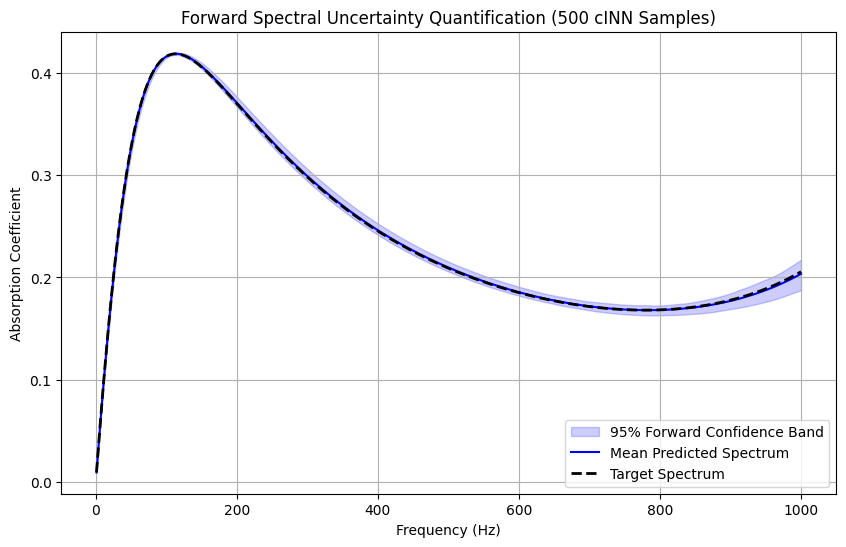

In [36]:
# ### 6. Uncertainty Quantification & Posterior Analysis
import scipy.stats as stats

def evaluate_cinn_uncertainty(test_idx, model, scaler, num_samples=500):
    model.eval()
    
    # 1. Prepare Target and Ground Truth
    target_spectrum = Y_test[test_idx]
    true_params_norm = X_test[test_idx]
    true_params_real = scaler.inverse_transform(true_params_norm.reshape(1, -1))[0]
    
    target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_samples, 1).to(device)
    z_random = torch.randn(num_samples, 20).to(device)
    
    # 2. Sample the Posterior (Generate 500 candidates)
    with torch.no_grad():
        generated_norm = model(z_random, target_tensor, rev=True)
        
        # Exact Likelihood of the Ground Truth (Metric 4)
        true_x_tensor = torch.FloatTensor(true_params_norm).unsqueeze(0).to(device)
        target_single = torch.FloatTensor(target_spectrum).unsqueeze(0).to(device)
        z_true, log_det_J = model(true_x_tensor, target_single, rev=False)
        true_nll = torch.mean(0.5 * torch.sum(z_true**2, dim=1) - log_det_J).item()
        
    generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
    generated_params = validate_and_clip_parameters(generated_params)
    
    # 3. Parameter Uncertainty (Metric 1 & 2)
    param_means = np.mean(generated_params, axis=0)
    param_stds = np.std(generated_params, axis=0)
    cov = (param_stds / (param_means + 1e-8)) * 100 # Coefficient of Variation (%)
    
    # 95% Confidence Intervals for Parameters
    lower_bound_95 = np.percentile(generated_params, 2.5, axis=0)
    upper_bound_95 = np.percentile(generated_params, 97.5, axis=0)
    
    # Calculate PICP (How many true parameters fall inside the 95% CI?)
    in_bounds = (true_params_real >= lower_bound_95) & (true_params_real <= upper_bound_95)
    picp = np.mean(in_bounds) * 100
    
    # 4. Spectral Uncertainty (Metric 3)
    print(f"Running TMM Physics Engine for {num_samples} posterior samples...")
    simulated_spectra = batch_physics_evaluation(generated_params)
    
    mean_spectrum = np.mean(simulated_spectra, axis=0)
    std_spectrum = np.std(simulated_spectra, axis=0)
    spectral_lower_95 = np.percentile(simulated_spectra, 2.5, axis=0)
    spectral_upper_95 = np.percentile(simulated_spectra, 97.5, axis=0)
    
    # --- PRINT REPORT ---
    print("\n" + "="*50)
    print(" cINN UNCERTAINTY QUANTIFICATION REPORT")
    print("="*50)
    print(f"1. Mean Coefficient of Variation (CoV):  {np.mean(cov):.2f}%")
    print(f"   (Higher % means the model found high physical degeneracy)")
    print(f"2. Parameter 95% PICP:                   {picp:.1f}%")
    print(f"   (Ideally close to 95.0%, meaning true physics are bounded)")
    print(f"3. Mean Spectral Forward Std Dev:        {np.mean(std_spectrum):.4f}")
    print(f"   (Low value means all 500 designs yield the exact same curve)")
    print(f"4. Ground Truth Exact NLL:               {true_nll:.4f}")
    print(f"   (Highly negative means the model strongly predicted the truth)")
    print("="*50)
    
    # --- PLOTTING SPECTRAL UNCERTAINTY ---
    frequencies = np.arange(1, 1001)
    plt.figure(figsize=(10, 6))
    
    # Plot 95% Confidence Band
    plt.fill_between(frequencies, spectral_lower_95, spectral_upper_95, color='blue', alpha=0.2, label='95% Forward Confidence Band')
    
    # Plot Mean Prediction and Target
    plt.plot(frequencies, mean_spectrum, color='blue', label='Mean Predicted Spectrum')
    plt.plot(frequencies, target_spectrum, color='black', linestyle='--', linewidth=2, label='Target Spectrum')
    
    plt.title('Forward Spectral Uncertainty Quantification (500 cINN Samples)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Absorption Coefficient')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Run the evaluation on the first test sample
evaluate_cinn_uncertainty(test_idx=0, model=model, scaler=scaler_params, num_samples=500)


🧪 STARTING COMPREHENSIVE cINN VALIDATION SUITE

TEST 1: FORWARD-INVERSE CYCLE CONSISTENCY

📊 Results from 50 tests:
   Spectrum MAE:   Mean=0.001313, Max=0.012965
   Parameter MAE:  Mean=627992.48, Max=2179241.86

✅ PASS if Spectrum MAE < 0.01
⚠️  Parameter MAE is high due to one-to-many degeneracy (expected)

TEST 2: INVERSE-FORWARD CONSISTENCY (SELF-CONSISTENCY)
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidates through physics engine...
Evaluating 10 cINN generated candidate

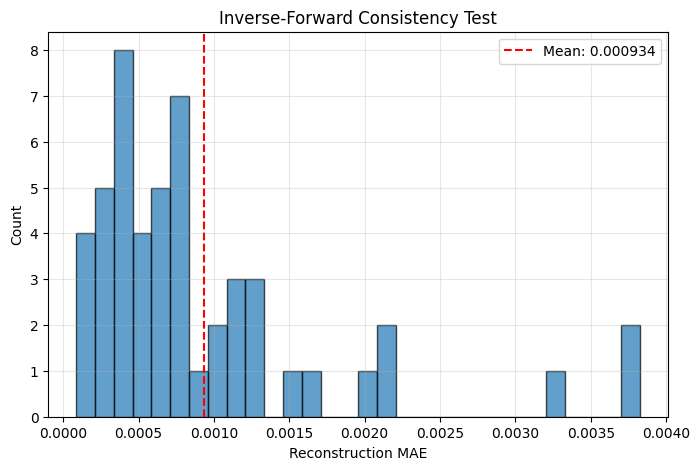


TEST 3: LATENT SPACE GAUSSIANITY (Normalizing Flow Validation)

📊 Testing 1000 samples across 20 latent dimensions:
   Mean p-value: 0.2438
   Dimensions passing (p > 0.05): 15/20 (75.0%)

✅ PASS if > 15/20 dimensions are Gaussian (p > 0.05)


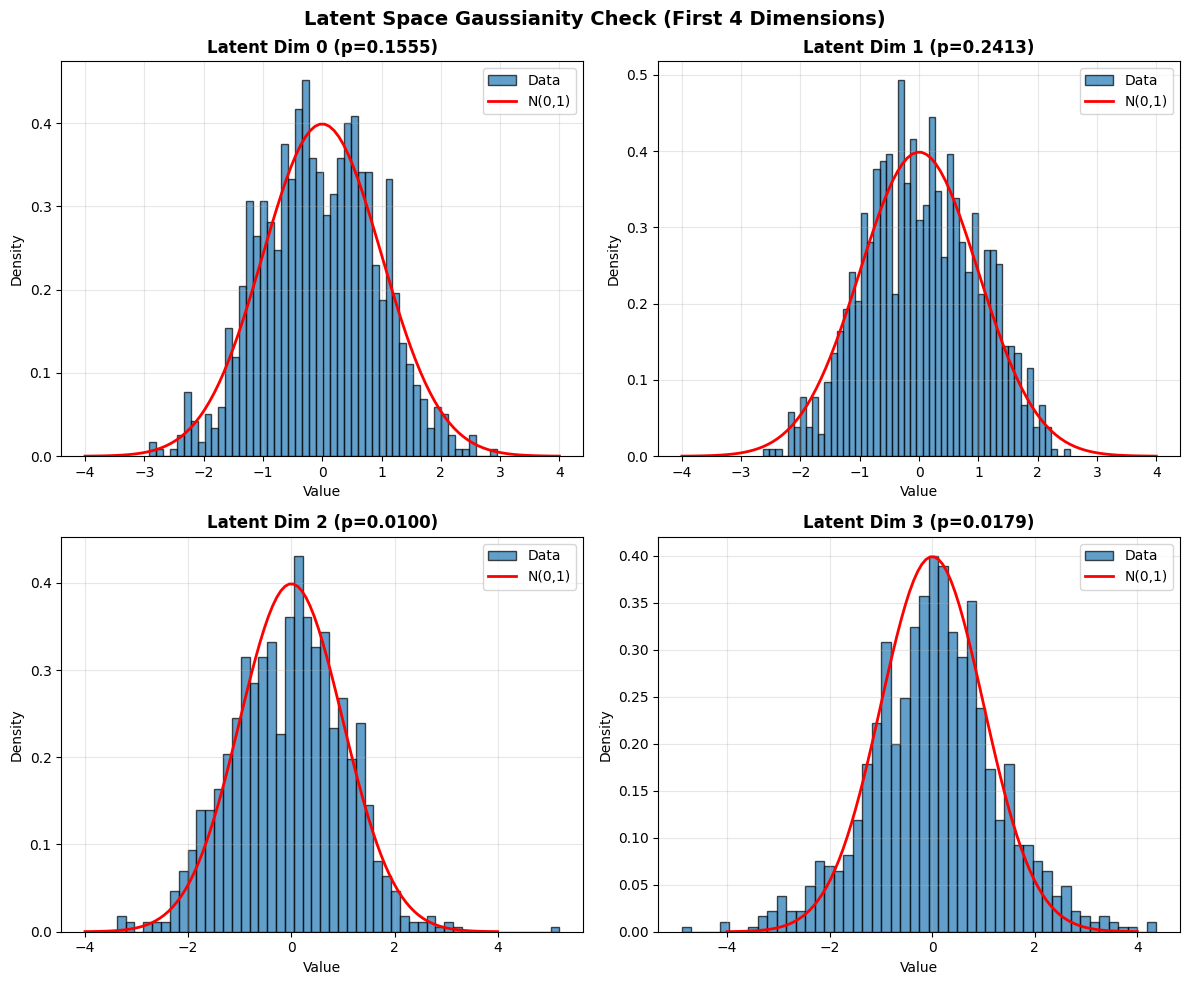


TEST 4: PARAMETER DIVERSITY (One-to-Many Capability)

📊 Diversity Metrics (100 candidates):
   Mean pairwise Euclidean distance: 19435528.55
   Std dev:                          14036372.39
   Min distance:                     7969.68
   Max distance:                     79985552.01

📊 Per-parameter Standard Deviations:
   d1   :     5.60
   d2   :     5.13
   d3   :     5.16
   d4   :     5.27
   d5   :     5.49
   d6   :     5.44
   d7   :     5.51
   d8   :     5.69
   d9   :     5.62
   d10  :     5.44
   m2   :   513.22
   m3   :   515.05
   m5   :   495.99
   m6   :   490.34
   m8   :   538.00
   m9   :   558.23
   rho  :   137.99
   eta  :     0.00
   E    : 16867304.48
   nu   :     0.03

✅ PASS if mean distance > 10 (parameters are diverse)


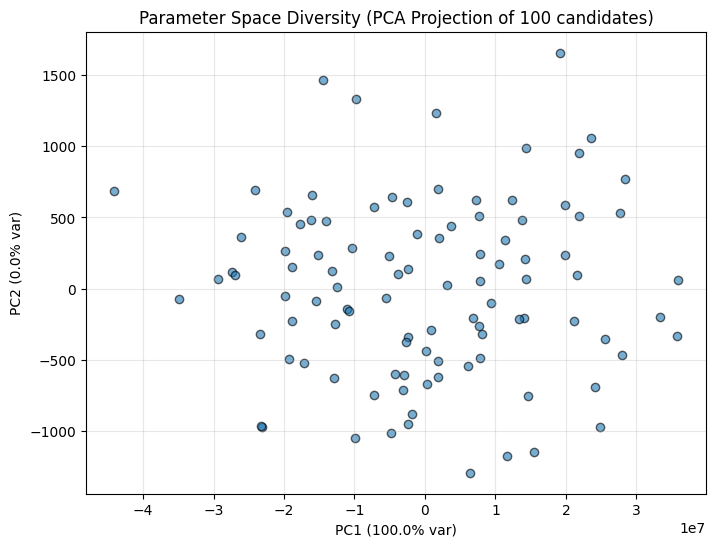


TEST 5: OUT-OF-DISTRIBUTION ROBUSTNESS

🔍 Testing: Flat 50% absorption
Evaluating 10 cINN generated candidates through physics engine...
   ✅ RMSE=0.1273, MAE=0.1100, R²=-inf

🔍 Testing: Linear ramp 0→1
Evaluating 10 cINN generated candidates through physics engine...
   ✅ RMSE=0.2011, MAE=0.1653, R²=0.5155

🔍 Testing: Step function
Evaluating 10 cINN generated candidates through physics engine...
   ✅ RMSE=0.3383, MAE=0.2686, R²=0.5421

🔍 Testing: High freq oscillation
Evaluating 10 cINN generated candidates through physics engine...
   ✅ RMSE=0.2567, MAE=0.2167, R²=-0.4578

✅ Model should gracefully handle OOD spectra (may not fit perfectly)

TEST 6: JACOBIAN DETERMINANT STABILITY

📊 Jacobian Statistics:
   Mean log|det(J)|: 15.8508
   Std dev:          1.7967
   Min:              11.7927
   Max:              20.2453
   NaN values:       0
   Inf values:       0

✅ PASS if NaN=0 and Inf=0


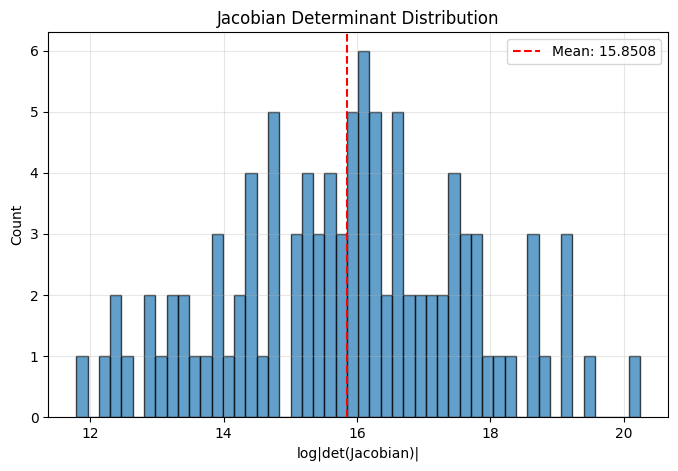


✅ VALIDATION SUITE COMPLETE


In [49]:
def test_forward_inverse_consistency(model, scaler, num_tests=50):
    """
    Test if: Real Params → TMM → Spectrum → cINN → Predicted Params
    results in similar parameters (accounting for degeneracy).
    """
    print("\n" + "="*70)
    print("TEST 1: FORWARD-INVERSE CYCLE CONSISTENCY")
    print("="*70)
    
    model.eval()
    param_errors = []
    spectrum_errors = []
    
    for idx in range(num_tests):
        # Get real parameters and their spectrum
        real_params_norm = X_test[idx]
        real_params = scaler.inverse_transform(real_params_norm.reshape(1, -1))[0]
        target_spectrum = Y_test[idx]
        
        # Generate candidates via cINN
        target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(10, 1).to(device)
        z_random = torch.randn(10, 20).to(device)
        
        with torch.no_grad():
            generated_norm = model(z_random, target_tensor, rev=True)
        
        generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
        generated_params = validate_and_clip_parameters(generated_params)
        
        # Run all candidates through physics
        simulated_spectra = batch_physics_evaluation(generated_params)
        
        # Find best match
        rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
        best_idx = np.argmin(rmses)
        best_params = generated_params[best_idx]
        best_spectrum = simulated_spectra[best_idx]
        
        # Calculate errors
        param_mae = np.mean(np.abs(best_params - real_params))
        spectrum_mae = np.mean(np.abs(best_spectrum - target_spectrum))
        
        param_errors.append(param_mae)
        spectrum_errors.append(spectrum_mae)
    
    print(f"\n📊 Results from {num_tests} tests:")
    print(f"   Spectrum MAE:   Mean={np.mean(spectrum_errors):.6f}, Max={np.max(spectrum_errors):.6f}")
    print(f"   Parameter MAE:  Mean={np.mean(param_errors):.2f}, Max={np.max(param_errors):.2f}")
    print(f"\n✅ PASS if Spectrum MAE < 0.01")
    print(f"⚠️  Parameter MAE is high due to one-to-many degeneracy (expected)")
    
    return param_errors, spectrum_errors


def test_inverse_forward_consistency(model, scaler, num_tests=50):
    """
    Test if: Target Spectrum → cINN → Params → TMM → Reconstructed Spectrum
    returns the same spectrum.
    """
    print("\n" + "="*70)
    print("TEST 2: INVERSE-FORWARD CONSISTENCY (SELF-CONSISTENCY)")
    print("="*70)
    
    model.eval()
    reconstruction_errors = []
    
    for idx in range(num_tests):
        target_spectrum = Y_test[idx]
        
        # cINN inverse design
        best_params, best_spectrum, _ = inverse_design_cinn(
            target_spectrum, model, scaler, num_candidates=10
        )
        
        # Calculate reconstruction error
        mae = np.mean(np.abs(best_spectrum - target_spectrum))
        reconstruction_errors.append(mae)
    
    print(f"\n📊 Reconstruction Error Statistics:")
    print(f"   Mean MAE: {np.mean(reconstruction_errors):.6f}")
    print(f"   Median:   {np.median(reconstruction_errors):.6f}")
    print(f"   Max:      {np.max(reconstruction_errors):.6f}")
    print(f"   Std:      {np.std(reconstruction_errors):.6f}")
    
    print(f"\n✅ PASS if Mean MAE < 0.01")
    
    # Plot distribution
    plt.figure(figsize=(8, 5))
    plt.hist(reconstruction_errors, bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(np.mean(reconstruction_errors), color='r', linestyle='--', 
                label=f'Mean: {np.mean(reconstruction_errors):.6f}')
    plt.xlabel('Reconstruction MAE')
    plt.ylabel('Count')
    plt.title('Inverse-Forward Consistency Test')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return reconstruction_errors

def test_latent_gaussianity(model, X_test, Y_test, num_samples=1000):
    """
    Test if the latent space follows N(0, I) distribution.
    """
    print("\n" + "="*70)
    print("TEST 3: LATENT SPACE GAUSSIANITY (Normalizing Flow Validation)")
    print("="*70)
    
    model.eval()
    
    # Sample random test data
    sample_indices = np.random.choice(len(X_test), num_samples, replace=False)
    
    all_z = []
    for idx in sample_indices:
        x = torch.FloatTensor(X_test[idx]).unsqueeze(0).to(device)
        c = torch.FloatTensor(Y_test[idx]).unsqueeze(0).to(device)
        
        with torch.no_grad():
            z, _ = model(x, c, rev=False)
        
        all_z.append(z.cpu().numpy()[0])
    
    all_z = np.array(all_z)  # Shape: (num_samples, 20)
    
    # Test each latent dimension
    print(f"\n📊 Testing {num_samples} samples across 20 latent dimensions:")
    
    ks_pvalues = []
    for dim in range(20):
        # Kolmogorov-Smirnov test against N(0, 1)
        statistic, pvalue = stats.kstest(all_z[:, dim], 'norm', args=(0, 1))
        ks_pvalues.append(pvalue)
    
    mean_pvalue = np.mean(ks_pvalues)
    num_pass = np.sum(np.array(ks_pvalues) > 0.05)  # p > 0.05 means accept null (Gaussian)
    
    print(f"   Mean p-value: {mean_pvalue:.4f}")
    print(f"   Dimensions passing (p > 0.05): {num_pass}/20 ({100*num_pass/20:.1f}%)")
    
    print(f"\n✅ PASS if > 15/20 dimensions are Gaussian (p > 0.05)")
    
    # Visualize first 4 dimensions
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for i, ax in enumerate(axes.flat):
        ax.hist(all_z[:, i], bins=50, density=True, alpha=0.7, edgecolor='black', label='Data')
        
        # Overlay theoretical N(0,1)
        x_range = np.linspace(-4, 4, 100)
        ax.plot(x_range, stats.norm.pdf(x_range, 0, 1), 'r-', linewidth=2, label='N(0,1)')
        
        ax.set_title(f'Latent Dim {i} (p={ks_pvalues[i]:.4f})', fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Latent Space Gaussianity Check (First 4 Dimensions)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return ks_pvalues, all_z

def test_parameter_diversity(model, scaler, test_idx=0, num_candidates=100):
    """
    Test if cINN generates diverse candidates for the same target.
    """
    print("\n" + "="*70)
    print("TEST 4: PARAMETER DIVERSITY (One-to-Many Capability)")
    print("="*70)
    
    model.eval()
    target_spectrum = Y_test[test_idx]
    
    # Generate many candidates
    target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
    z_random = torch.randn(num_candidates, 20).to(device)
    
    with torch.no_grad():
        generated_norm = model(z_random, target_tensor, rev=True)
    
    generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
    generated_params = validate_and_clip_parameters(generated_params)
    
    # Calculate pairwise distances
    from scipy.spatial.distance import pdist
    
    pairwise_dists = pdist(generated_params, metric='euclidean')
    mean_dist = np.mean(pairwise_dists)
    std_dist = np.std(pairwise_dists)
    
    print(f"\n📊 Diversity Metrics ({num_candidates} candidates):")
    print(f"   Mean pairwise Euclidean distance: {mean_dist:.2f}")
    print(f"   Std dev:                          {std_dist:.2f}")
    print(f"   Min distance:                     {np.min(pairwise_dists):.2f}")
    print(f"   Max distance:                     {np.max(pairwise_dists):.2f}")
    
    # Check per-parameter std dev
    param_stds = np.std(generated_params, axis=0)
    print(f"\n📊 Per-parameter Standard Deviations:")
    for i, (name, std_val) in enumerate(zip(PARAM_NAMES, param_stds)):
        print(f"   {name:5s}: {std_val:>8.2f}")
    
    print(f"\n✅ PASS if mean distance > 10 (parameters are diverse)")
    
    # Visualize diversity in 2D (PCA)
    from sklearn.decomposition import PCA
    
    pca = PCA(n_components=2)
    coords_2d = pca.fit_transform(generated_params)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.6, edgecolors='black')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
    plt.title(f'Parameter Space Diversity (PCA Projection of {num_candidates} candidates)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return generated_params, pairwise_dists

def test_ood_robustness(model, scaler):
    """
    Test cINN on synthetic spectra it has never seen.
    """
    print("\n" + "="*70)
    print("TEST 5: OUT-OF-DISTRIBUTION ROBUSTNESS")
    print("="*70)
    
    model.eval()
    
    # Create synthetic test cases
    synthetic_spectra = {
        "Flat 50% absorption": np.ones(1000) * 0.5,
        "Linear ramp 0→1": np.linspace(0, 1, 1000),
        "Step function": np.concatenate([np.zeros(500), np.ones(500)]),
        "High freq oscillation": 0.5 + 0.3 * np.sin(np.arange(1000) * 0.1),
    }
    
    results = {}
    
    for name, spectrum in synthetic_spectra.items():
        print(f"\n🔍 Testing: {name}")
        
        try:
            best_params, best_pred, rmse = inverse_design_cinn(
                spectrum, model, scaler, num_candidates=10
            )
            
            mae = np.mean(np.abs(best_pred - spectrum))
            r2 = 1 - (np.sum((spectrum - best_pred)**2) / np.sum((spectrum - np.mean(spectrum))**2))
            
            results[name] = {
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'success': True
            }
            
            print(f"   ✅ RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
            
        except Exception as e:
            results[name] = {'success': False, 'error': str(e)}
            print(f"   ❌ FAILED: {e}")
    
    print(f"\n✅ Model should gracefully handle OOD spectra (may not fit perfectly)")
    
    return results

def test_jacobian_stability(model, X_test, Y_test, num_samples=100):
    """
    Test if log|det(J)| values are stable (not NaN/Inf).
    """
    print("\n" + "="*70)
    print("TEST 6: JACOBIAN DETERMINANT STABILITY")
    print("="*70)
    
    model.eval()
    
    log_det_values = []
    
    for idx in range(min(num_samples, len(X_test))):
        x = torch.FloatTensor(X_test[idx]).unsqueeze(0).to(device)
        c = torch.FloatTensor(Y_test[idx]).unsqueeze(0).to(device)
        
        with torch.no_grad():
            _, log_det_J = model(x, c, rev=False)
        
        log_det_values.append(log_det_J.item())
    
    log_det_values = np.array(log_det_values)
    
    num_nan = np.sum(np.isnan(log_det_values))
    num_inf = np.sum(np.isinf(log_det_values))
    
    print(f"\n📊 Jacobian Statistics:")
    print(f"   Mean log|det(J)|: {np.mean(log_det_values):.4f}")
    print(f"   Std dev:          {np.std(log_det_values):.4f}")
    print(f"   Min:              {np.min(log_det_values):.4f}")
    print(f"   Max:              {np.max(log_det_values):.4f}")
    print(f"   NaN values:       {num_nan}")
    print(f"   Inf values:       {num_inf}")
    
    print(f"\n✅ PASS if NaN=0 and Inf=0")
    
    # Plot distribution
    plt.figure(figsize=(8, 5))
    plt.hist(log_det_values, bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(np.mean(log_det_values), color='r', linestyle='--', 
                label=f'Mean: {np.mean(log_det_values):.4f}')
    plt.xlabel('log|det(Jacobian)|')
    plt.ylabel('Count')
    plt.title('Jacobian Determinant Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return log_det_values


def run_full_validation_suite():
    """
    Execute all validation tests in sequence.
    """
    print("\n" + "="*80)
    print("🧪 STARTING COMPREHENSIVE cINN VALIDATION SUITE")
    print("="*80)
    
    results = {}
    
    # Test 1
    try:
        results['forward_inverse'], _ = test_forward_inverse_consistency(model, scaler_params, 50)
    except Exception as e:
        print(f"❌ Test 1 failed: {e}")
    
    # Test 2
    try:
        results['inverse_forward'] = test_inverse_forward_consistency(model, scaler_params, 50)
    except Exception as e:
        print(f"❌ Test 2 failed: {e}")
    
    # Test 3
    try:
        results['latent_pvalues'], _ = test_latent_gaussianity(model, X_test, Y_test, 1000)
    except Exception as e:
        print(f"❌ Test 3 failed: {e}")
    
    # Test 4
    try:
        _, results['diversity_dists'] = test_parameter_diversity(model, scaler_params, 0, 100)
    except Exception as e:
        print(f"❌ Test 4 failed: {e}")
    
    # Test 5
    try:
        results['ood'] = test_ood_robustness(model, scaler_params)
    except Exception as e:
        print(f"❌ Test 5 failed: {e}")
    
    # Test 6
    try:
        results['jacobians'] = test_jacobian_stability(model, X_test, Y_test, 100)
    except Exception as e:
        print(f"❌ Test 6 failed: {e}")
    
    print("\n" + "="*80)
    print("✅ VALIDATION SUITE COMPLETE")
    print("="*80)
    
    return results

# Execute all tests
validation_results = run_full_validation_suite()